In [93]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    if not hasattr(np, "bool"):
        np.bool = np.bool_
from qpython import qconnection


import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller



In [2]:

HOST = "hfm.princeton.edu"
PORT = 6007
RETRY_PORT = 6009
RETRY_INTERVAL = 5


def open_kdb_connection(host=HOST, port=RETRY_PORT):
    while True:
        try:
            q = qconnection.QConnection(
                host=host,
                port=port,
                pandas=False,
            )
            q.open()
            return q
        except Exception as e:
            print(f"Connection failed: {e}")
            time.sleep(RETRY_INTERVAL)


def safe_execute(db, query):
    try:
        return db(query), db
    except Exception:
        try:
            db.close()
        except Exception:
            pass
        db = open_kdb_connection()
        return db(query), db

try:
    db = qconnection.QConnection(
        host=HOST,
        port=PORT,
        pandas=False,
    )
    db.open()
except Exception:
    db = open_kdb_connection()


In [3]:
def to_pandas(x):
    """Convert common kdb/PyKX/qpython outputs to a pandas DataFrame."""
    # If safe_execute returns (result, meta), unwrap
    if isinstance(x, tuple):
        x = x[0]

    if isinstance(x, pd.DataFrame):
        return x

    if isinstance(x, (np.recarray, np.ndarray)) and getattr(x, "dtype", None) is not None and x.dtype.names:
        return pd.DataFrame.from_records(x)

    if isinstance(x, dict):
        return pd.DataFrame(x)

    return pd.DataFrame(x)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def add_only_A_B_M_signal(
    df_prices: pd.DataFrame,
    window: int = 60,
    eps: float = 1e-8,
    col_prefix: str = "",
) -> pd.DataFrame:
    df = df_prices.copy()
    tickers = list(df.columns)
    N = len(tickers)
    alpha = float(np.exp(-1.0 / window))
    z = df.values.astype(float)
    T = z.shape[0]

    A = np.zeros(N, dtype=float)
    B = np.zeros(N, dtype=float)          # per-asset observed mass
    M = np.zeros((N, N), dtype=float)

    A_hist = np.zeros((T, N))
    B_hist = np.zeros((T, N))
    M_hist = np.zeros((T, N, N))
    s_hist = np.zeros((T, N))

    evr1_hist = np.full(T, np.nan, dtype=float)
    eval1_hist = np.full(T, np.nan, dtype=float)
    eval2_hist = np.full(T, np.nan, dtype=float)
    eval3_hist = np.full(T, np.nan, dtype=float) if N >= 3 else None

    for t in range(T):
        zt = z[t]
        mask = np.isfinite(zt).astype(float)

        # EW updates only where observed
        A = alpha * A + mask * zt
        B = alpha * B + mask

        z_filled = np.where(np.isfinite(zt), zt, 0.0)
        M = alpha * M + np.outer(z_filled, z_filled)

        mu = A / np.maximum(B, eps)

        Cov = M / np.maximum(np.mean(B), eps) - np.outer(mu, mu)
        Cov = 0.5 * (Cov + Cov.T)

        diag = np.diag(Cov)
        diag = np.where(np.isfinite(diag), diag, eps)
        sigma = np.sqrt(np.maximum(diag, eps))

        # eigen decomposition
        vals, vecs = np.linalg.eigh(Cov)

        # sort descending
        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        vals = np.maximum(vals, 0.0)   # numerical safeguard
        total_var = np.sum(vals)

        if total_var > eps:
            evr1 = vals[0] / total_var
        else:
            evr1 = np.nan

        v1 = vecs[:, 0]

        # standardized z
        z_std = (np.where(np.isfinite(zt), zt, mu) - mu) / sigma

        xi = float(v1.T @ z_std)
        z_hat = mu + (v1 * sigma) * xi
        s = z_hat - np.where(np.isfinite(zt), zt, z_hat)

        A_hist[t] = A
        B_hist[t] = B
        M_hist[t] = M
        s_hist[t] = s

        evr1_hist[t] = evr1
        eval1_hist[t] = vals[0] if len(vals) > 0 else np.nan
        eval2_hist[t] = vals[1] if len(vals) > 1 else np.nan
        if N >= 3:
            eval3_hist[t] = vals[2] if len(vals) > 2 else np.nan

    out = df.copy()

    for i, tk in enumerate(tickers):
        out[f"{col_prefix}A_{tk}"] = A_hist[:, i]
        out[f"{col_prefix}s_{tk}"] = s_hist[:, i]
        out[f"{col_prefix}B_{tk}"] = B_hist[:, i]

    for i, tki in enumerate(tickers):
        for j, tkj in enumerate(tickers):
            out[f"{col_prefix}M_{tki}_{tkj}"] = M_hist[:, i, j]

    # EVR / eigenvalue diagnostics
    out[f"{col_prefix}evr1"] = evr1_hist
    out[f"{col_prefix}lambda1"] = eval1_hist
    out[f"{col_prefix}lambda2"] = eval2_hist
    if N >= 3:
        out[f"{col_prefix}lambda3"] = eval3_hist

    return out


def attach_datetime_from_ns_index(df: pd.DataFrame, date_str: str) -> pd.DataFrame:
    """Index is ns since midnight; anchor to date_str."""
    td = pd.to_timedelta(df.index.astype("int64"), unit="ns")
    base = pd.to_datetime(date_str)
    out = df.copy()
    out.index = base + td
    out.index.name = "datetime"
    return out


def plot_asset(df: pd.DataFrame, ticker: str, color: str):
    p = df[ticker].astype(float)
    z_hat = (df[ticker] + df[f"s_{ticker}"]).astype(float)
    t = df.index  # datetime index

    fig = plt.figure(figsize=(11, 6), facecolor="white")
    fig.text(0.05, 0.92, "Time series and forecasts", fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    # price
    ax.step(t, p, where="post", linewidth=2.4, color=color, label=f"{ticker} (price)")

    # forecast (NO regression, just your PCA projection)
    ax.step(t, z_hat, where="post", linewidth=1.6, color=color, alpha=0.35, label="forecast")

    # clean axes
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)

    ax.set_yticks([])

    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xticks([t.min(), t.max()])

    # date annotation
    ax.text(
        0.98, 0.98, f"{t.min().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    # legend
    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    plt.show()


def plot_evr(
    df: pd.DataFrame,
    evr_col: str = "evr1",
    title: str = "Rolling EVR of PC1",
    color: str = "#7a3db8",
    add_regime_band: bool = True,
    high_thresh: float = 0.80,
    low_thresh: float = 0.65,
):
    s = df[evr_col].astype(float)
    t = df.index

    fig = plt.figure(figsize=(11, 5.2), facecolor="white")
    fig.text(0.05, 0.92, title, fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    ax.plot(t, s, linewidth=2.4, color=color, label="EVR1")

    if add_regime_band:
        ax.axhline(
            high_thresh,
            color="firebrick",
            linestyle="--",
            linewidth=1.4,
            alpha=0.85,
            label=f"high={high_thresh:.2f}",
        )
        ax.axhline(
            low_thresh,
            color="teal",
            linestyle="--",
            linewidth=1.4,
            alpha=0.85,
            label=f"low={low_thresh:.2f}",
        )
        ax.fill_between(
            t,
            high_thresh,
            1.0,
            color="firebrick",
            alpha=0.08,
        )

    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)

    ax.set_ylabel("EVR", fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.18)

    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    n_ticks = 8
    tick_pos = pd.date_range(t.min(), t.max(), periods=n_ticks)
    ax.set_xticks(tick_pos)

    ax.text(
        0.98, 0.98, f"{t.min().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    plt.show()


def run_oneday_pipeline(
    db,
    date_quotes: str = "2024.02.15",
    date_active: str = "2024.02.15",
    insts=("RB", "CL","HO"),
    window: int = 60,
    eps: float = 1e-8,
    scale_prices_by_100: bool = True,
    make_scatter: bool = True,
):
    """
    End-to-end:
      1) query active symbols from kdb (top 8 by sum siz) on date_active
      2) pull 1-minute midprices for those syms on date_quotes
      3) build CLJ4/RBJ4 scatter
      4) compute EW stats + PCA-projection signal for CLJ4,RBJ4,HOJ4
      5) attach datetime index and plot each asset separately + EVR

    Returns:
      sym_active, df_midprice_all, df_dt, df_oneday
    """
    # ---- helpers (local, so function is self-contained) ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    # ---- 1) active symbols ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # ---- 2) pull midprices ----
    df_midprice_all = None

    for sym in sym_active:
        q_mid = f"""
        aj[`time;
            ([] time: (0D00:00:00 + 0D00:01:00 * til 961));
            select midprice1: (last bid + last ask) % 2 by time
            from quote where date={date_quotes}, sym=`{sym}
        ]
        """
        raw = safe_execute(db, q_mid)
        df_sym = to_pandas(raw)

        if "time" not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'time' column.")

        if "midprice1" in df_sym.columns:
            df_sym = df_sym.rename(columns={"midprice1": sym})
        elif sym not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'midprice1' or '{sym}'.")

        df_midprice_all = df_sym if df_midprice_all is None else df_midprice_all.merge(df_sym, on="time", how="left")

    # ---- 3) optional scaling ----
    df_midprice_all = df_midprice_all.copy()
    if scale_prices_by_100:
        for sym in sym_active:
            if sym in df_midprice_all.columns:
                df_midprice_all[sym] = df_midprice_all[sym].astype(float) / 100.0

    # ---- 4) optional visualization for 3D: pairwise + 3D scatter ----
    if make_scatter:
        required_vis = ["CLJ4", "RBJ4", "HOJ4"]
        if set(required_vis).issubset(df_midprice_all.columns):
            df_sc = df_midprice_all[["time"] + required_vis].copy()

            # optional extra scaling for visualization only
            df_sc["RBJ4_scaled"] = df_sc["RBJ4"].astype(float) / 100.0
            df_sc["HOJ4_scaled"] = df_sc["HOJ4"].astype(float) / 100.0
            df_sc["CLJ4_scaled"] = df_sc["CLJ4"].astype(float)

            sns.set_style("whitegrid")

            pair_specs = [
                ("CLJ4_scaled", "RBJ4_scaled", "CLJ4", "RBJ4"),
                ("CLJ4_scaled", "HOJ4_scaled", "CLJ4", "HOJ4"),
                ("RBJ4_scaled", "HOJ4_scaled", "RBJ4", "HOJ4"),
            ]

            for xcol, ycol, xlab, ylab in pair_specs:
                plt.figure(figsize=(8, 6))
                plt.plot(
                    df_sc[xcol],
                    df_sc[ycol],
                    alpha=0.35,
                    linewidth=0.4,
                )
                plt.scatter(
                    df_sc[xcol],
                    df_sc[ycol],
                    alpha=0.75,
                    s=18,
                )
                plt.grid(which="minor", visible=False)
                plt.title(f"{xlab} vs {ylab}", fontsize=18, fontweight="bold", color="darkorange")
                plt.xlabel(xlab)
                plt.ylabel(ylab)
                plt.tight_layout()
                plt.show()

            from mpl_toolkits.mplot3d import Axes3D

            fig = plt.figure(figsize=(9, 7))
            ax = fig.add_subplot(111, projection="3d")

            ax.scatter(
                df_sc["CLJ4_scaled"],
                df_sc["RBJ4_scaled"],
                df_sc["HOJ4_scaled"],
                s=12,
                alpha=0.65,
            )

            ax.set_title("3D Scatter: CLJ4 vs RBJ4 vs HOJ4", fontsize=16, fontweight="bold")
            ax.set_xlabel("CLJ4")
            ax.set_ylabel("RBJ4")
            ax.set_zlabel("HOJ4")

            plt.tight_layout()
            plt.show()

    # ---- 5) compute signal for CLJ4/RBJ4/HOJ4 ----
    required_cols = ["CLJ4", "RBJ4", "HOJ4"]

    if not set(required_cols).issubset(df_midprice_all.columns):
        raise ValueError(f"Missing required columns: {required_cols}")

    data_one = df_midprice_all[["time"] + required_cols].copy().set_index("time")

    df_oneday = add_only_A_B_M_signal(data_one, window=window, eps=eps)

    # ---- 6) attach datetime + plot ----
    date_anchor = date_quotes.replace(".", "-")
    df_dt = attach_datetime_from_ns_index(df_oneday, date_anchor)

    plot_asset(df_dt, "CLJ4", "darkorange")
    plot_asset(df_dt, "RBJ4", "navy")
    plot_asset(df_dt, "HOJ4", "green")

    return sym_active, df_midprice_all, df_dt, df_oneday

Active symbols: ['CLJ4', 'CLH4', 'RBJ4', 'CLK4', 'HOJ4', 'HOH4', 'RBH4', 'CLZ4']


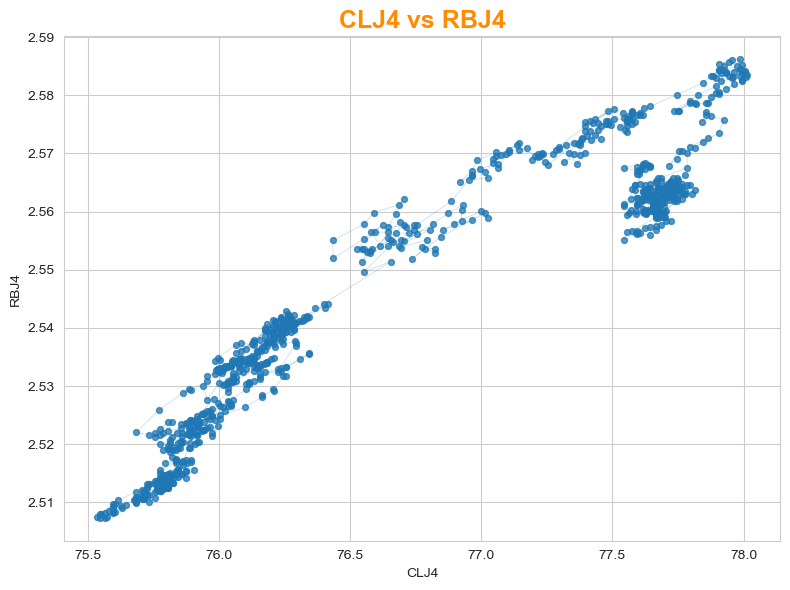

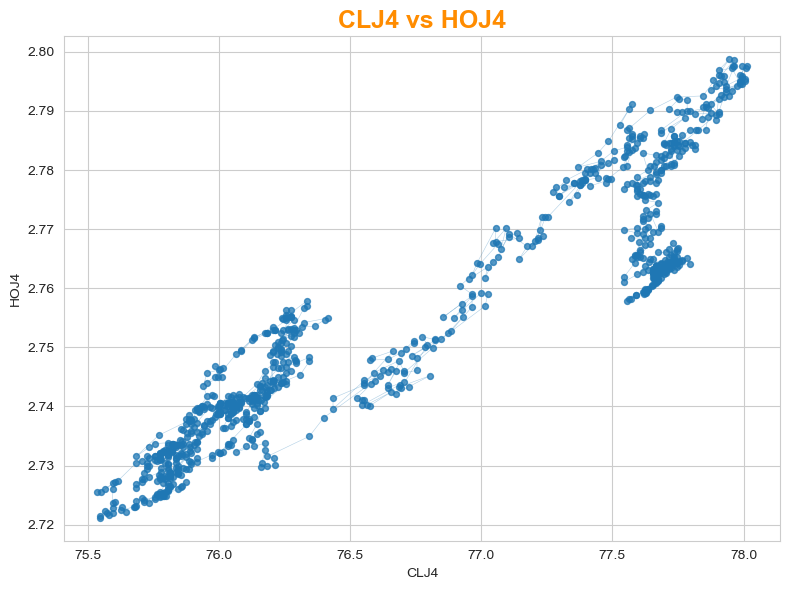

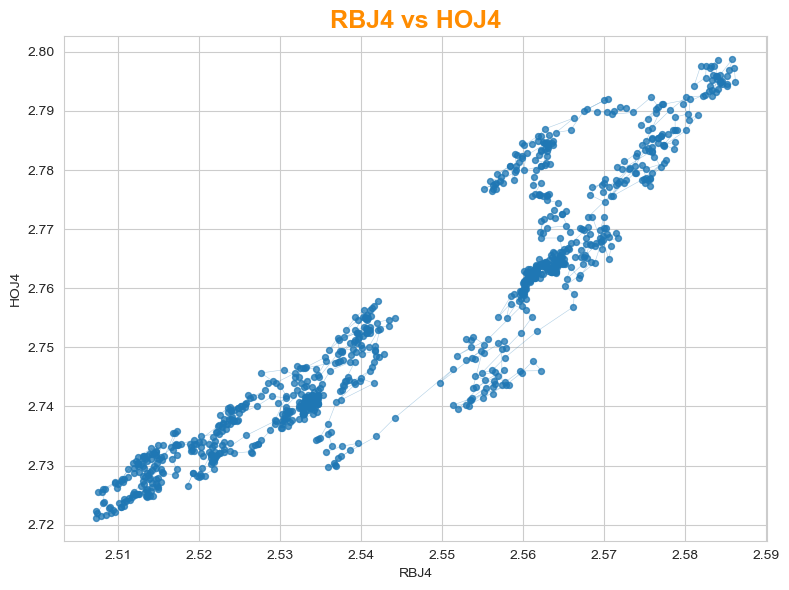

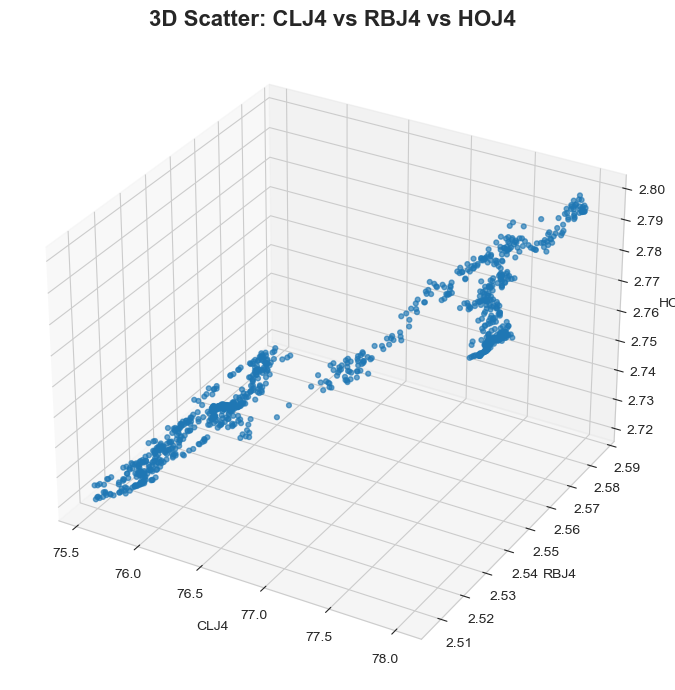

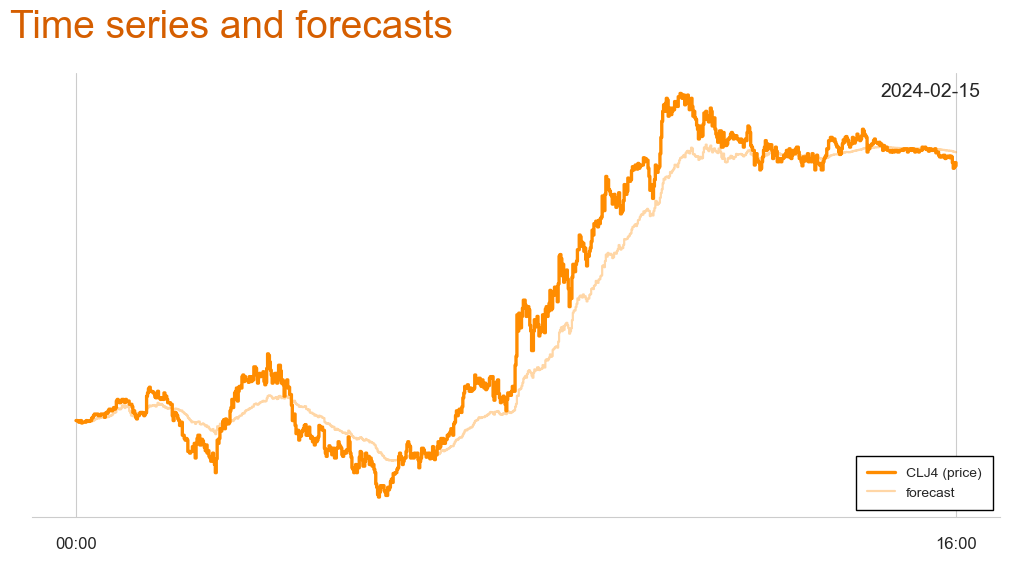

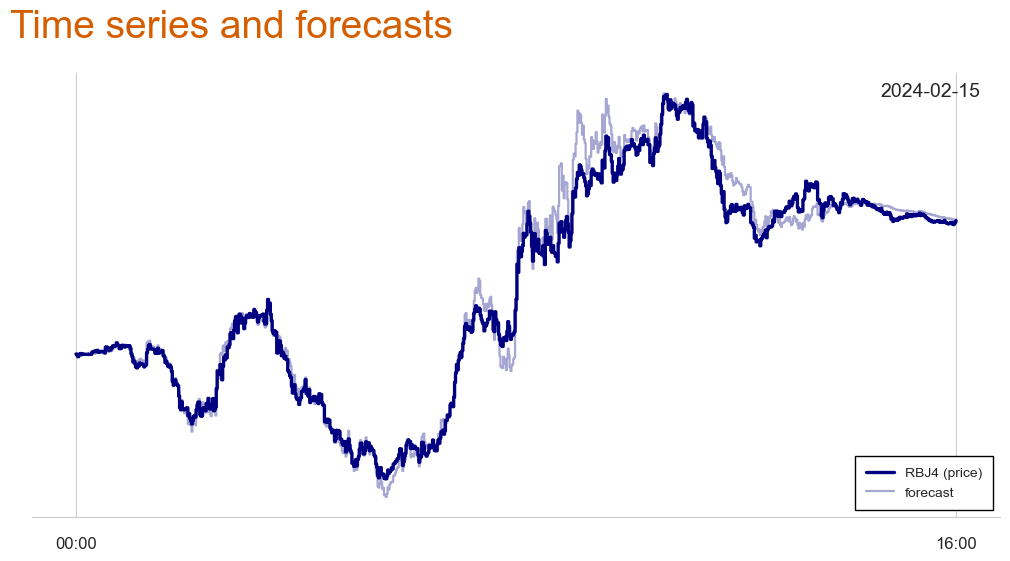

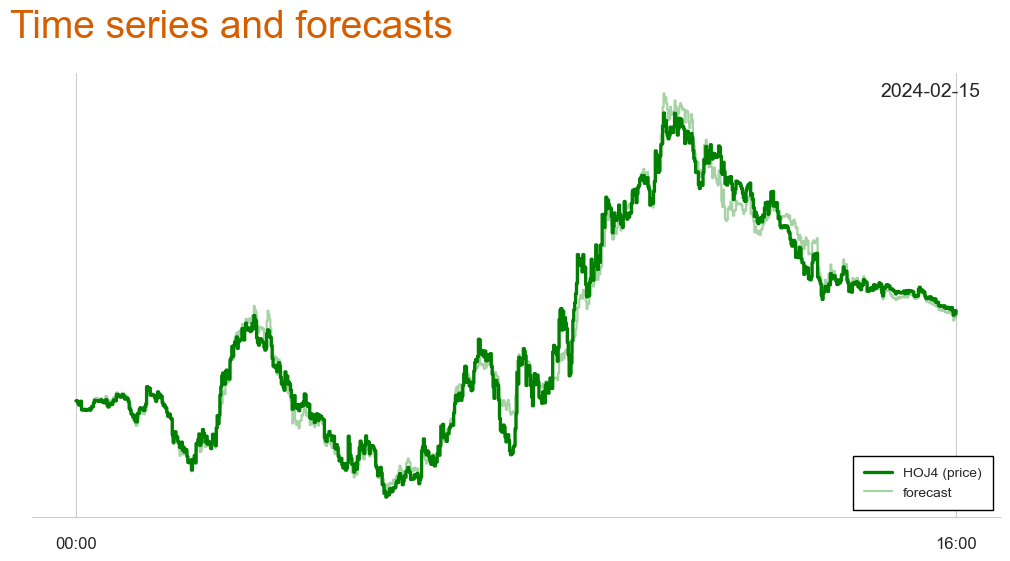

(['CLJ4', 'CLH4', 'RBJ4', 'CLK4', 'HOJ4', 'HOH4', 'RBH4', 'CLZ4'],
                time    CLJ4    CLH4     RBJ4    CLK4     HOJ4     HOH4  \
 0                 0  76.005  76.260  253.295  75.775  274.060  279.570   
 1       60000000000  76.005  76.260  253.265  75.770  274.055  279.565   
 2      120000000000  76.000  76.250  253.240  75.770  274.005  279.525   
 3      180000000000  75.995  76.250  253.290  75.760  273.975  279.485   
 4      240000000000  76.000  76.250  253.285  75.770  274.015  279.525   
 ..              ...     ...     ...      ...     ...      ...      ...   
 956  57360000000000  77.590  78.080  255.960  77.200  275.880  281.595   
 957  57420000000000  77.555  78.050  255.950  77.165  275.790  281.510   
 958  57480000000000  77.565  78.060  255.975  77.175  275.815  281.535   
 959  57540000000000  77.590  78.090  256.010  77.200  275.880  281.595   
 960  57600000000000  77.570  78.065  256.030  77.175  275.820  281.535   
 
         RBH4    CLZ4  
 0    2

In [4]:
run_oneday_pipeline(db)

# Using More data

In [5]:
def plot_asset_trading_time(df, ticker: str, show_signal: bool = False):
    """
    Plot without calendar gaps (trading time index).

    Actual   = red
    Forecast = black dashed

    Optional:
        show_signal=True -> adds alpha signal subplot (z_hat - price)
    """
    df = df.sort_index()

    p = df[ticker].astype(float).values
    z_hat = (df[ticker] + df[f"s_{ticker}"]).astype(float).values
    signal = z_hat - p

    # trading-time index
    x = np.arange(len(df))

    # trading dates
    dates = df.index.normalize()
    unique_dates, date_positions = np.unique(dates, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)   # <-- fix

    if show_signal:
        fig, (ax, ax2) = plt.subplots(
            2, 1, figsize=(11, 7),
            gridspec_kw={"height_ratios": [3, 1]},
            facecolor="white"
        )
    else:
        fig = plt.figure(figsize=(11, 6), facecolor="white")
        ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    fig.text(0.05, 0.92, "Time series and forecasts",
             fontsize=28, color="#d55e00")

    # main plot
    ax.plot(x, p, linewidth=2.8, color="red", label=f"{ticker} (Actual)")
    ax.plot(x, z_hat, linewidth=2.2, linestyle="--", color="black", alpha=0.9, label="Forecast")

    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)

    ax.set_yticks([])

    ax.set_xticks(date_positions)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    ax.legend(
        loc="lower right",
        frameon=True,
        framealpha=1.0,
        fancybox=False,
        borderpad=0.8
    )

    if show_signal:
        ax2.plot(x, signal, linewidth=1.8, label="Signal")
        ax2.axhline(0, linestyle="--", linewidth=1.0, alpha=0.7)

        for sp in ["top", "right", "left"]:
            ax2.spines[sp].set_visible(False)

        ax2.set_yticks([])
        ax2.set_xticks(date_positions)
        ax2.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)
        ax2.legend(loc="lower right", frameon=False)

    plt.tight_layout()
    plt.show()
def plot_evr_multiday(
    df: pd.DataFrame,
    evr_col: str = "evr1",
    high_thresh: float = 0.80,
    low_thresh: float = 0.65,
    color: str = "#7a3db8",
    y_min: float = 0.7,
    y_max: float = 1.0,
):
    s = df[evr_col].astype(float)
    t = df.index

    fig = plt.figure(figsize=(13, 5.5), facecolor="white")
    fig.text(0.05, 0.92, "EVR Regime (Zoomed)", fontsize=26, color="#d55e00")

    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    # EVR line
    ax.plot(t, s, linewidth=2.2, color=color, label="EVR1")


    # shading ONLY in visible range
    ax.fill_between(
        t,
        np.maximum(high_thresh, y_min),
        y_max,
        where=(s >= high_thresh),
        color="firebrick",
        alpha=0.10,
    )

    # styling
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)

    ax.set_ylim(y_min, y_max)
    ax.set_ylabel("EVR")

    ax.grid(axis="y", alpha=0.15)

    ax.tick_params(axis="x", which="major", length=8, width=1.1, direction="out")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    # legend
    leg = ax.legend(loc="lower right", frameon=True)
    leg.get_frame().set_edgecolor("black")
    ax.set_ylim(0.7, 1.0)
    plt.show()


In [6]:
def run_multiday_pipeline_concat(
    db,
    start_date: str = "2024-02-01",
    end_date: str = "2024-02-29",
    date_active: str = "2024.02.05",
    insts=("RB", "CL", "HO"),
    window: int = 60,
    eps: float = 1e-8,
    make_scatter: bool = True,
    cl_scale: float = 100,       # CL* raw maybe stored as price * 100
    rb_scale: float = 10000,     # RB* raw maybe stored as price * 10000
    ho_scale: float = 10000,     # HO* raw maybe stored as price * 10000

    time_grid_q: str = "(0D00:00:00 + 0D00:01:00 * til 961)",
    drop_all_nan_rows: bool = True,
):
    """
    Concatenate all dates into a single df, then:
      1) find active symbols once
      2) pull midprices for all dates
      3) scale by instrument family
      4) optional scatter without regression line
      5) compute EW stats + PCA-projection signal
      6) plot trading-time series for each asset
    """

    # ---- local helpers ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    def _prefix(sym: str) -> str:
        s = str(sym).upper()
        if len(s) >= 2:
            return s[:2]
        return s

    def _scale_for_sym(sym: str) -> float:
        pfx = _prefix(sym)
        if pfx == "CL":
            return cl_scale
        elif pfx == "RB":
            return rb_scale
        elif pfx == "HO":
            return ho_scale
        else:
            return 1.0

    # ---- (1) active symbols (ONCE) ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # ---- (2) pull midprices for ALL dates and concat ----
    dates = pd.date_range(start_date, end_date, freq="D")
    dates_q = [d.strftime("%Y.%m.%d") for d in dates]

    all_days = []

    for date_quotes in dates_q:
        df_midprice_all = None

        for sym in sym_active:
            q_mid = f"""
            aj[`time;
                ([] time: {time_grid_q});
                select midprice1: (last bid + last ask) % 2 by time
                from quote where date={date_quotes}, sym=`{sym}
            ]
            """
            raw = safe_execute(db, q_mid)
            df_sym = to_pandas(raw)

            if df_sym is None or len(df_sym) == 0:
                continue

            if "time" not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'time' column.")

            if "midprice1" in df_sym.columns:
                df_sym = df_sym.rename(columns={"midprice1": sym})
            elif sym not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'midprice1' or '{sym}'.")

            df_midprice_all = (
                df_sym if df_midprice_all is None
                else df_midprice_all.merge(df_sym, on="time", how="left")
            )

        if df_midprice_all is None or df_midprice_all.empty:
            continue

        df_midprice_all = df_midprice_all.copy()

        # ---- (3) instrument-aware scaling ----
        for sym in sym_active:
            if sym not in df_midprice_all.columns:
                continue
            scale = _scale_for_sym(sym)
            df_midprice_all[sym] = df_midprice_all[sym].astype(float) / scale

        # drop rows where ALL prices are NaN
        if drop_all_nan_rows:
            price_cols = [c for c in df_midprice_all.columns if c != "time"]
            df_midprice_all = df_midprice_all.dropna(subset=price_cols, how="all")

        if df_midprice_all.empty:
            continue

        # add date + datetime
        date_anchor = date_quotes.replace(".", "-")
        df_midprice_all["date"] = date_quotes
        df_midprice_all["datetime"] = (
            pd.to_datetime(date_anchor) +
            pd.to_timedelta(df_midprice_all["time"].astype("int64"), unit="ns")
        )

        all_days.append(df_midprice_all)

    if len(all_days) == 0:
        raise ValueError("No days returned data in the requested range.")

    df_mid_all = pd.concat(all_days, ignore_index=True)
    df_mid_all = df_mid_all.sort_values("datetime").reset_index(drop=True)

    # ---- infer required columns for state model ----
    required_cols = [c for c in ["CLJ4", "RBJ4", "HOJ4", "HLJ4"] if c in df_mid_all.columns]

    # keep the canonical 2D/3D combinations only
    if {"CLJ4", "RBJ4", "HOJ4"}.issubset(df_mid_all.columns):
        required_cols = ["CLJ4", "RBJ4", "HOJ4"]
    elif {"CLJ4", "RBJ4"}.issubset(df_mid_all.columns):
        required_cols = ["CLJ4", "RBJ4"]
    elif {"CLJ4", "HLJ4", "RBJ4"}.issubset(df_mid_all.columns):
        required_cols = ["CLJ4", "RBJ4", "HLJ4"]

    if len(required_cols) < 2:
        raise ValueError("Need at least two required columns such as CLJ4/RBJ4 or CLJ4/RBJ4/HOJ4.")

    print("Required columns used for signal:", required_cols)

    # ---- (4) ONE scatter plot over ALL dates (NO regression line) ----
    if make_scatter:
        if {"CLJ4", "RBJ4"}.issubset(df_mid_all.columns):
            df_sc = df_mid_all[["CLJ4", "RBJ4"]].dropna()

            plt.figure(figsize=(8, 6))
            plt.plot(df_sc["CLJ4"], df_sc["RBJ4"], alpha=0.35, linewidth=0.4)
            plt.scatter(df_sc["CLJ4"], df_sc["RBJ4"], alpha=0.75, s=18)
            plt.grid(which="minor", visible=False)
            plt.title("CLJ4 vs RBJ4 (All Dates)", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("CLJ4")
            plt.ylabel("RBJ4")
            plt.tight_layout()
            plt.show()

        if {"CLJ4", "HOJ4"}.issubset(df_mid_all.columns):
            df_sc = df_mid_all[["CLJ4", "HOJ4"]].dropna()

            plt.figure(figsize=(8, 6))
            plt.plot(df_sc["CLJ4"], df_sc["HOJ4"], alpha=0.35, linewidth=0.4)
            plt.scatter(df_sc["CLJ4"], df_sc["HOJ4"], alpha=0.75, s=18)
            plt.grid(which="minor", visible=False)
            plt.title("CLJ4 vs HOJ4 (All Dates)", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("CLJ4")
            plt.ylabel("HOJ4")
            plt.tight_layout()
            plt.show()

        if {"RBJ4", "HOJ4"}.issubset(df_mid_all.columns):
            df_sc = df_mid_all[["RBJ4", "HOJ4"]].dropna()

            plt.figure(figsize=(8, 6))
            plt.plot(df_sc["RBJ4"], df_sc["HOJ4"], alpha=0.35, linewidth=0.4)
            plt.scatter(df_sc["RBJ4"], df_sc["HOJ4"], alpha=0.75, s=18)
            plt.grid(which="minor", visible=False)
            plt.title("RBJ4 vs HOJ4 (All Dates)", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("RBJ4")
            plt.ylabel("HOJ4")
            plt.tight_layout()
            plt.show()

    # ---- (5) compute EW stats + PCA-projection signal ----
    prices = df_mid_all[["datetime"] + required_cols].copy()
    prices = prices.set_index("datetime")

    # for PCA state, drop rows where any required asset is missing
    prices = prices.dropna(subset=required_cols, how="any")

    if prices.empty:
        raise ValueError("After dropping missing required prices, no rows remain for signal construction.")

    df_state_all = add_only_A_B_M_signal(prices, window=window, eps=eps)

    # ---- (6) plot each asset once ----
    # ---- (6) plot assets + EVR ----
    for ticker in required_cols:
        plot_asset_trading_time(df_state_all, ticker)

    return sym_active, df_mid_all, df_state_all

In [7]:
# ============================================================
# DISCRETE 3-ASSET RULE + RL
# Each asset trades integer contracts directly
# action_i in {-2,-1,0,1,2}
# inventory_i in [-2,2]
# No hedge ratio, no portfolio normalization
# ============================================================


# ============================================================
# Utilities
# ============================================================

def clip_int(x: int, lo: int, hi: int) -> int:
    return int(min(max(int(x), lo), hi))


def mean_daily_pnl(reward: pd.Series) -> float:
    daily = reward.groupby(reward.index.normalize()).sum()
    return float(daily.mean())


def max_daily_drawdown(reward: pd.Series) -> float:
    daily = reward.resample("1D").sum()
    cum = daily.cumsum()
    dd = cum - cum.cummax()
    return float(dd.min())




def make_walkforward_zscore(
    signal: pd.Series,
    window: int,
    min_periods: int | None = None,
    lag: int = 1,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    s = signal.astype(float)

    if min_periods is None:
        min_periods = max(20, window // 5)

    mu = s.rolling(window, min_periods=min_periods).mean().shift(lag)
    sd = s.rolling(window, min_periods=min_periods).std(ddof=0).shift(lag)
    sd = sd.replace(0.0, np.nan)

    z = (s - mu) / sd
    return z, mu, sd


# ============================================================
# Build discrete 3-asset input from df_state_all
# Uses s_* columns directly as per-asset signals
# ============================================================

def build_discrete_3asset_input(
    df_state_all: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    col_c: str,
    use_price_fallback: bool = False,
) -> pd.DataFrame:
    df = df_state_all.copy().sort_index()

    s_a = f"s_{col_a}"
    s_b = f"s_{col_b}"
    s_c = f"s_{col_c}"

    needed_s = [s_a, s_b, s_c]
    if all(c in df.columns for c in needed_s):
        df["sig_a"] = df[s_a].astype(float)
        df["sig_b"] = df[s_b].astype(float)
        df["sig_c"] = df[s_c].astype(float)
    else:
        if not use_price_fallback:
            raise ValueError(f"Missing residual columns among {needed_s}.")
        df["sig_a"] = df[col_a].astype(float)
        df["sig_b"] = df[col_b].astype(float)
        df["sig_c"] = df[col_c].astype(float)

    out = df[[col_a, col_b, col_c, "sig_a", "sig_b", "sig_c"]].dropna().copy()
    return out


# ============================================================
# Rule action from z-score for one asset
# action in {-2,-1,0,1,2}
# ============================================================

def rule_action_from_z(
    z_t: float,
    z_flat: float = 1,
    z_entry: float = 2,
    z_strong: float = 3,
) -> int:
    if not np.isfinite(z_t):
        return 0

    if abs(z_t) <= z_flat:
        return 0
    elif z_t >= z_strong:
        return 2
    elif z_t >= z_entry:
        return 1
    elif z_t <= -z_strong:
        return -2
    elif z_t <= -z_entry:
        return -1
    else:
        return 0


# ============================================================
# RULE-BASED DISCRETE 3-ASSET STRATEGY
# Each asset trades directly using its own z-score
# ============================================================

def run_rule_3asset_discrete(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    col_c: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    sig_c: str = "sig_c",
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    inv_limit: int = 2,
    z_flat: float = 0.5,
    z_entry: float = 1.0,
    z_strong: float = 2.0,
    mult_a: float = 1.0,
    mult_b: float = 1.0,
    mult_c: float = 1.0,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.0,
):
    df = df.sort_index().copy()

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)
    Pc = df[col_c].astype(float)

    za, za_mu, za_sd = make_walkforward_zscore(df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag)
    zb, zb_mu, zb_sd = make_walkforward_zscore(df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag)
    zc, zc_mu, zc_sd = make_walkforward_zscore(df[sig_c], window=z_window, min_periods=z_min_periods, lag=z_lag)

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]
    dPc_next = (Pc.shift(-1) - Pc).iloc[:-1]

    idx = df.index[:-1]

    na_prev, nb_prev, nc_prev = 0, 0, 0

    dates = []
    aa_list, ab_list, ac_list = [], [], []
    na_list, nb_list, nc_list = [], [], []
    reward_list = []
    za_used, zb_used, zc_used = [], [], []

    for k in range(len(idx)):
        t = idx[k]

        z_a_t = float(za.iloc[k]) if np.isfinite(za.iloc[k]) else np.nan
        z_b_t = float(zb.iloc[k]) if np.isfinite(zb.iloc[k]) else np.nan
        z_c_t = float(zc.iloc[k]) if np.isfinite(zc.iloc[k]) else np.nan

        # these are TARGET POSITIONS, not trade increments
        n_a = rule_action_from_z(z_a_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)
        n_b = rule_action_from_z(z_b_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)
        n_c = rule_action_from_z(z_c_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)

        # executed trade size
        dn_a = n_a - na_prev
        dn_b = n_b - nb_prev
        dn_c = n_c - nc_prev

        dPa = float(dPa_next.iloc[k])
        dPb = float(dPb_next.iloc[k])
        dPc = float(dPc_next.iloc[k])

        gross = (
            n_a * dPa * mult_a +
            n_b * dPb * mult_b +
            n_c * dPc * mult_c
        )

        trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b) + abs(dn_c))
        inventory_cost = inv_penalty * (abs(n_a) + abs(n_b) + abs(n_c))

        R = gross - trade_cost - inventory_cost

        dates.append(t)
        aa_list.append(dn_a)   # actual trade
        ab_list.append(dn_b)
        ac_list.append(dn_c)
        na_list.append(n_a)    # position
        nb_list.append(n_b)
        nc_list.append(n_c)
        reward_list.append(R)
        za_used.append(z_a_t)
        zb_used.append(z_b_t)
        zc_used.append(z_c_t)

        na_prev, nb_prev, nc_prev = n_a, n_b, n_c

    dt = pd.DatetimeIndex(dates)
    reward = pd.Series(reward_list, index=dt, name="reward_$")
    cum = reward.cumsum().rename("cum_reward_$")

    actions_df = pd.DataFrame({
        f"a_{col_a}": aa_list,
        f"a_{col_b}": ab_list,
        f"a_{col_c}": ac_list,
    }, index=dt)

    n_df = pd.DataFrame({
        f"n_{col_a}": na_list,
        f"n_{col_b}": nb_list,
        f"n_{col_c}": nc_list,
    }, index=dt)

    z_df = pd.DataFrame({
        f"z_{col_a}": za_used,
        f"z_{col_b}": zb_used,
        f"z_{col_c}": zc_used,
    }, index=dt)

    return {
        "strategy": "rule_3asset_discrete",
        "reward": reward,
        "cum": cum,
        "actions": actions_df,
        "n": n_df,
        "z_used": z_df,
        "metrics": {
            "mean_daily_pnl_$": mean_daily_pnl(reward),
            "max_drawdown_daily_$": max_daily_drawdown(reward),
        },
    }

# ============================================================
# RL 3-ASSET TABULAR Q-LEARNING (ADAPTIVE / FORGETTING)
# action = (a_a, a_b, a_c), each in {-2,-1,0,1,2}
# inventory per asset in [-2,2]
# same state as before, but algorithm improved for non-stationarity
# ============================================================

from collections import defaultdict
import numpy as np
import pandas as pd


def train_q_learning_3asset_discrete_adaptive(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    col_c: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    sig_c: str = "sig_c",
    train_end: str = "2024-02-15",
    inv_limit: int = 2,
    action_values = (-2, -1, 0, 1, 2),
    gamma: float = 0.99,
    lr: float = 0.05,
    epochs: int = 80,
    eps_start: float = 0.20,
    eps_end: float = 0.05,
    seed: int = 0,
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    z_step: float = 0.5,
    z_clip: float | None = 5.0,
    mult_a: float = 1.0,
    mult_b: float = 1.0,
    mult_c: float = 1.0,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.1,

    # -------- new adaptive / non-stationary controls --------
    q_decay: float = 0.998,          # forgetting factor on Q
    use_adaptive_lr: bool = False,   # optional visitation-based lr
    lr_visit_scale: float = 0.01,    # adaptive lr denominator scale
    reset_every: int | None = None,  # e.g. 20 to periodically reset Q
    persistent_exploration: float = 0.02,  # keeps exploration alive
):
    rng = np.random.default_rng(seed)
    df = df.sort_index().copy()

    train_mask = df.index <= pd.Timestamp(train_end)
    test_mask = ~train_mask

    if train_mask.sum() < 200:
        raise ValueError("Training set too small.")
    if test_mask.sum() < 200:
        raise ValueError("Test set too small.")

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)
    Pc = df[col_c].astype(float)

    za, _, _ = make_walkforward_zscore(
        df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag
    )
    zb, _, _ = make_walkforward_zscore(
        df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag
    )
    zc, _, _ = make_walkforward_zscore(
        df[sig_c], window=z_window, min_periods=z_min_periods, lag=z_lag
    )

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]
    dPc_next = (Pc.shift(-1) - Pc).iloc[:-1]

    idx = df.index[:-1]

    def quantize_z(zs: pd.Series) -> pd.Series:
        vals = zs.iloc[:-1].astype(float).values
        out = np.empty(len(vals), dtype=float)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                out[i] = 0.0
                continue
            if z_clip is not None:
                v = float(np.clip(v, -z_clip, z_clip))
            out[i] = float(z_step * np.round(v / z_step))
        return pd.Series(out, index=idx, dtype=float)

    zqa = quantize_z(za)
    zqb = quantize_z(zb)
    zqc = quantize_z(zc)

    one_dim_actions = np.array(sorted(set(int(a) for a in action_values)), dtype=int)
    joint_actions = [(a, b, c) for a in one_dim_actions for b in one_dim_actions for c in one_dim_actions]
    n_actions = len(joint_actions)

    def q_get(Q, s, a_idx):
        return Q.get((s, a_idx), 0.0)

    def q_set(Q, s, a_idx, val):
        Q[(s, a_idx)] = val

    Q = {}
    N = defaultdict(int)

    train_mask_rl = train_mask[:-1]
    train_idx = np.where(train_mask_rl)[0]
    train_start, train_end_i = int(train_idx[0]), int(train_idx[-1])

    # ---------------- TRAIN ----------------
    for ep in range(epochs):
        if reset_every is not None and ep > 0 and (ep % reset_every == 0):
            Q = {}
            N = defaultdict(int)

        eps_sched = eps_start + (eps_end - eps_start) * (ep / max(1, epochs - 1))
        eps = max(eps_end, eps_sched) + persistent_exploration

        na_prev, nb_prev, nc_prev = 0, 0, 0

        for k in range(train_start, train_end_i + 1):
            s_t = (
                float(zqa.iloc[k]),
                float(zqb.iloc[k]),
                float(zqc.iloc[k]),
                int(na_prev),
                int(nb_prev),
                int(nc_prev),
            )

            if rng.random() < eps:
                a_idx = int(rng.integers(0, n_actions))
            else:
                q_vals = np.array([q_get(Q, s_t, j) for j in range(n_actions)], dtype=float)
                a_idx = int(np.argmax(q_vals))

            a_a, a_b, a_c = joint_actions[a_idx]

            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)
            n_c = clip_int(nc_prev + a_c, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev
            dn_c = n_c - nc_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])
            dPc = float(dPc_next.iloc[k])

            gross = (
                n_a * dPa * mult_a +
                n_b * dPb * mult_b +
                n_c * dPc * mult_c
            )

            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b) + abs(dn_c))

            # quadratic inventory penalty
            inventory_cost = inv_penalty * (n_a**2 + n_b**2 + n_c**2)

            pnl = gross - trade_cost
            R = pnl - inventory_cost

            if k == train_end_i:
                td_target = R
            else:
                s_next = (
                    float(zqa.iloc[k + 1]),
                    float(zqb.iloc[k + 1]),
                    float(zqc.iloc[k + 1]),
                    int(n_a),
                    int(n_b),
                    int(n_c),
                )
                q_next = np.array([q_get(Q, s_next, j) for j in range(n_actions)], dtype=float)
                td_target = R + gamma * float(np.max(q_next))

            q_old = q_get(Q, s_t, a_idx)

            N[(s_t, a_idx)] += 1
            if use_adaptive_lr:
                lr_eff = lr / (1.0 + lr_visit_scale * N[(s_t, a_idx)])
            else:
                lr_eff = lr

            # -------- adaptive forgetting update --------
            # old q fades via q_decay, new info enters via TD error
            q_new = q_decay * q_old + lr_eff * (td_target - q_old)

            q_set(Q, s_t, a_idx, q_new)

            na_prev, nb_prev, nc_prev = n_a, n_b, n_c

    # ---------------- GREEDY BACKTEST ----------------
    def greedy_run(mask_np: np.ndarray):
        ks = np.where(mask_np[:-1])[0]

        na_prev, nb_prev, nc_prev = 0, 0, 0

        dates = []
        act_a, act_b, act_c = [], [], []
        n_a_list, n_b_list, n_c_list = [], [], []
        pnl_list = []
        reward_list = []
        gross_list = []
        trade_cost_list = []
        inv_cost_list = []
        za_used, zb_used, zc_used = [], [], []

        for k in ks:
            s_t = (
                float(zqa.iloc[k]),
                float(zqb.iloc[k]),
                float(zqc.iloc[k]),
                int(na_prev),
                int(nb_prev),
                int(nc_prev),
            )

            q_vals = np.array([q_get(Q, s_t, j) for j in range(n_actions)], dtype=float)
            a_idx = int(np.argmax(q_vals))

            a_a, a_b, a_c = joint_actions[a_idx]

            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)
            n_c = clip_int(nc_prev + a_c, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev
            dn_c = n_c - nc_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])
            dPc = float(dPc_next.iloc[k])

            gross = (
                n_a * dPa * mult_a +
                n_b * dPb * mult_b +
                n_c * dPc * mult_c
            )

            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b) + abs(dn_c))
            inventory_cost = inv_penalty * (n_a**2 + n_b**2 + n_c**2)

            pnl = gross - trade_cost
            R = pnl - inventory_cost

            dates.append(idx[k])
            act_a.append(a_a)
            act_b.append(a_b)
            act_c.append(a_c)
            n_a_list.append(n_a)
            n_b_list.append(n_b)
            n_c_list.append(n_c)

            gross_list.append(gross)
            trade_cost_list.append(trade_cost)
            inv_cost_list.append(inventory_cost)
            pnl_list.append(pnl)
            reward_list.append(R)

            za_used.append(float(za.iloc[k]) if np.isfinite(za.iloc[k]) else np.nan)
            zb_used.append(float(zb.iloc[k]) if np.isfinite(zb.iloc[k]) else np.nan)
            zc_used.append(float(zc.iloc[k]) if np.isfinite(zc.iloc[k]) else np.nan)

            na_prev, nb_prev, nc_prev = n_a, n_b, n_c

        dt = pd.DatetimeIndex(dates)

        gross_s = pd.Series(gross_list, index=dt, name="gross_$")
        trade_cost_s = pd.Series(trade_cost_list, index=dt, name="trade_cost_$")
        inv_cost_s = pd.Series(inv_cost_list, index=dt, name="inventory_cost_$")
        pnl_s = pd.Series(pnl_list, index=dt, name="pnl_$")
        reward_s = pd.Series(reward_list, index=dt, name="reward_$")

        pnl_cum = pnl_s.cumsum().rename("cum_pnl_$")
        reward_cum = reward_s.cumsum().rename("cum_reward_$")

        actions_df = pd.DataFrame({
            f"a_{col_a}": act_a,
            f"a_{col_b}": act_b,
            f"a_{col_c}": act_c,
        }, index=dt)

        n_df = pd.DataFrame({
            f"n_{col_a}": n_a_list,
            f"n_{col_b}": n_b_list,
            f"n_{col_c}": n_c_list,
        }, index=dt)

        z_df = pd.DataFrame({
            f"z_{col_a}": za_used,
            f"z_{col_b}": zb_used,
            f"z_{col_c}": zc_used,
        }, index=dt)

        return {
            "gross": gross_s,
            "trade_cost": trade_cost_s,
            "inventory_cost": inv_cost_s,
            "pnl": pnl_s,
            "reward": reward_s,
            "cum_pnl": pnl_cum,
            "cum_reward": reward_cum,
            "actions": actions_df,
            "n": n_df,
            "z": z_df,
        }

    train_out = greedy_run(train_mask)
    test_out = greedy_run(test_mask)

    return {
        "Q": Q,
        "N": dict(N),
        "joint_actions": joint_actions,
        "inv_limit": inv_limit,

        "train_gross": train_out["gross"],
        "train_trade_cost": train_out["trade_cost"],
        "train_inventory_cost": train_out["inventory_cost"],
        "train_pnl": train_out["pnl"],
        "train_reward": train_out["reward"],
        "train_cum_pnl": train_out["cum_pnl"],
        "train_cum_reward": train_out["cum_reward"],
        "train_actions": train_out["actions"],
        "train_n": train_out["n"],
        "train_z": train_out["z"],

        "test_gross": test_out["gross"],
        "test_trade_cost": test_out["trade_cost"],
        "test_inventory_cost": test_out["inventory_cost"],
        "test_pnl": test_out["pnl"],
        "test_reward": test_out["reward"],
        "test_cum_pnl": test_out["cum_pnl"],
        "test_cum_reward": test_out["cum_reward"],
        "test_actions": test_out["actions"],
        "test_n": test_out["n"],
        "test_z": test_out["z"],

        "train_metrics": {
            "mean_daily_pnl_$": mean_daily_pnl(train_out["pnl"]),
            "max_drawdown_daily_$": max_daily_drawdown(train_out["pnl"]),
        },
        "test_metrics": {
            "mean_daily_pnl_$": mean_daily_pnl(test_out["pnl"]),
            "max_drawdown_daily_$": max_daily_drawdown(test_out["pnl"]),
        },
    }

def plot_trading_time_cum(cum: pd.Series, title: str):
    cum = cum.dropna()
    if cum.empty:
        return

    x = np.arange(len(cum))
    dates = cum.index.normalize()
    unique_dates, first_pos = np.unique(dates.values, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    fig = plt.figure(figsize=(11, 6), facecolor="white")
    fig.text(0.05, 0.92, title, fontsize=24, color="#d55e00")
    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    ax.plot(x, cum.values, linewidth=2.6, color="black", alpha=0.95)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.set_ylabel("Cumulative Reward ($)", fontsize=12)
    ax.set_xticks(first_pos)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    plt.show()

Active symbols: ['CLH4', 'CLJ4', 'HOH4', 'RBH4', 'RBJ4', 'CLK4', 'HOJ4', 'CLM4']
Required columns used for signal: ['CLJ4', 'RBJ4', 'HOJ4']


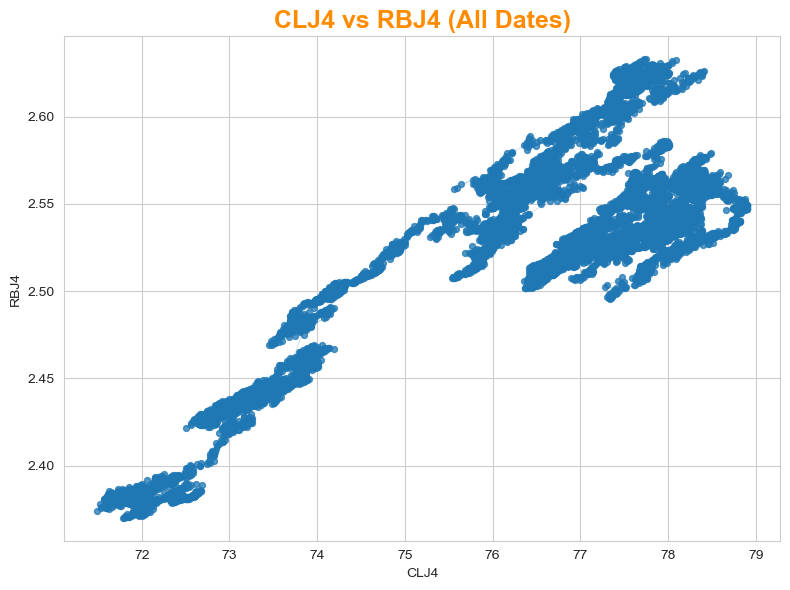

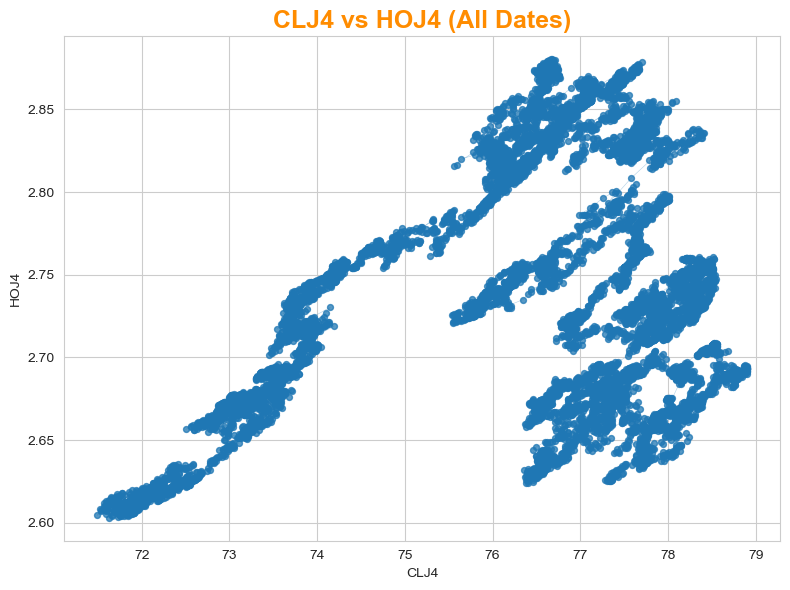

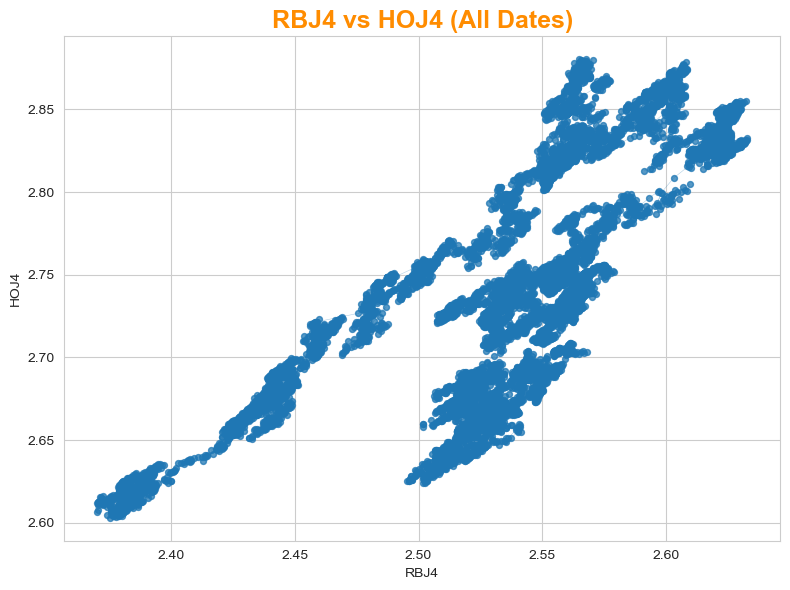

/var/folders/s0/f9jndhs915nb4p0s00wkw48m0000gn/T/ipykernel_87516/3611670697.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


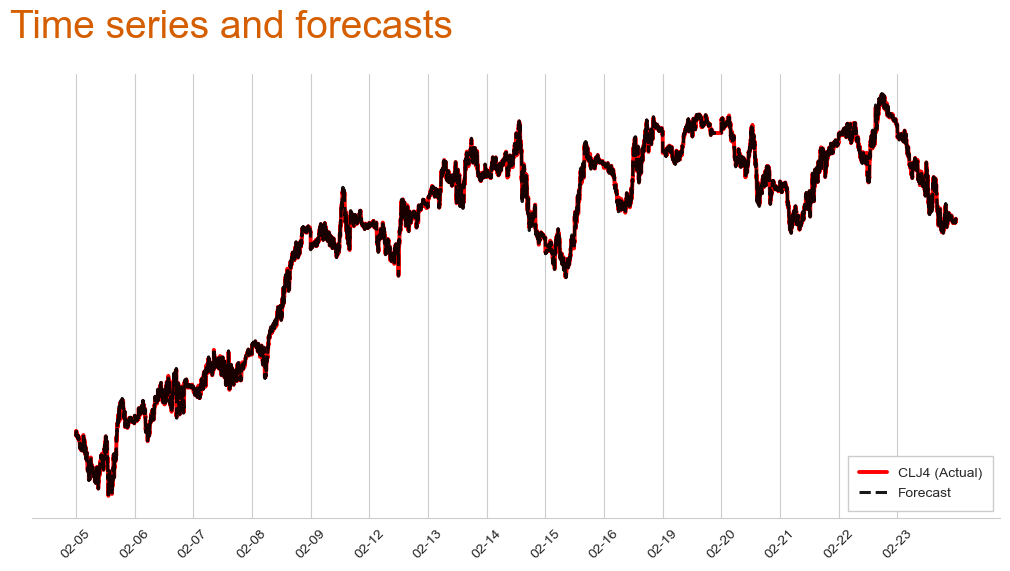

/var/folders/s0/f9jndhs915nb4p0s00wkw48m0000gn/T/ipykernel_87516/3611670697.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


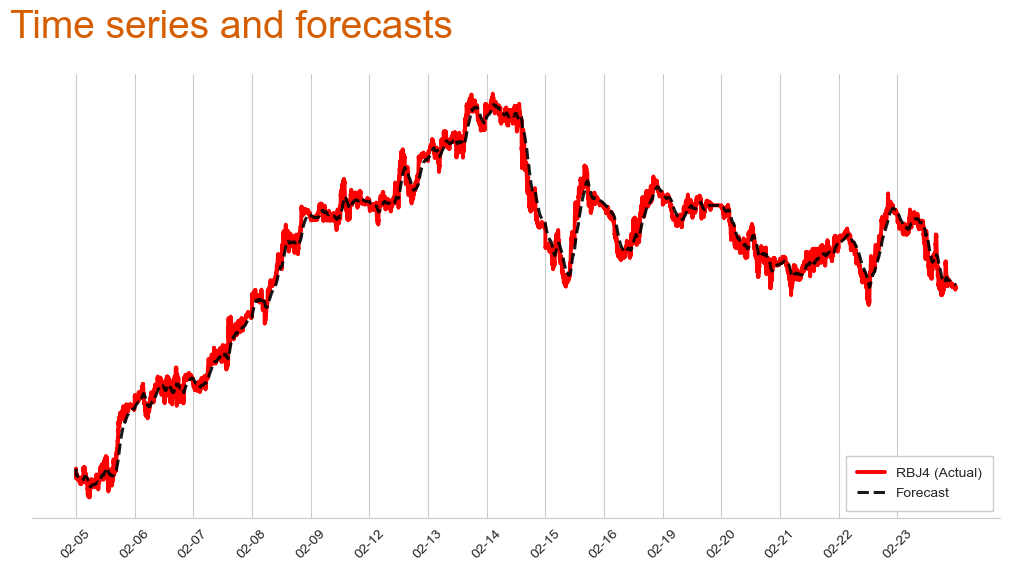

/var/folders/s0/f9jndhs915nb4p0s00wkw48m0000gn/T/ipykernel_87516/3611670697.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


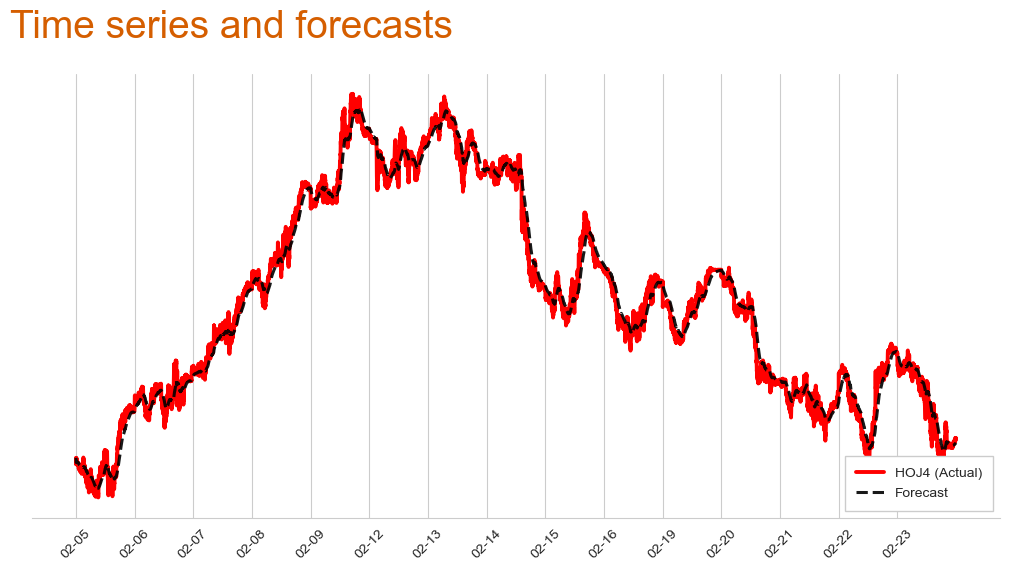

In [8]:
sym_active, df_mid_all, df_state_all = run_multiday_pipeline_concat(
    db,
    start_date="2024-02-01",
    end_date="2024-02-29",
    insts=("CL", "RB", "HO"),
)

df_3 = build_discrete_3asset_input(
    df_state_all,
    col_a="CLJ4",
    col_b="RBJ4",
    col_c="HOJ4",
) 

{'mean_daily_pnl_$': 1509.473333333356, 'max_drawdown_daily_$': -3738.300000000014}


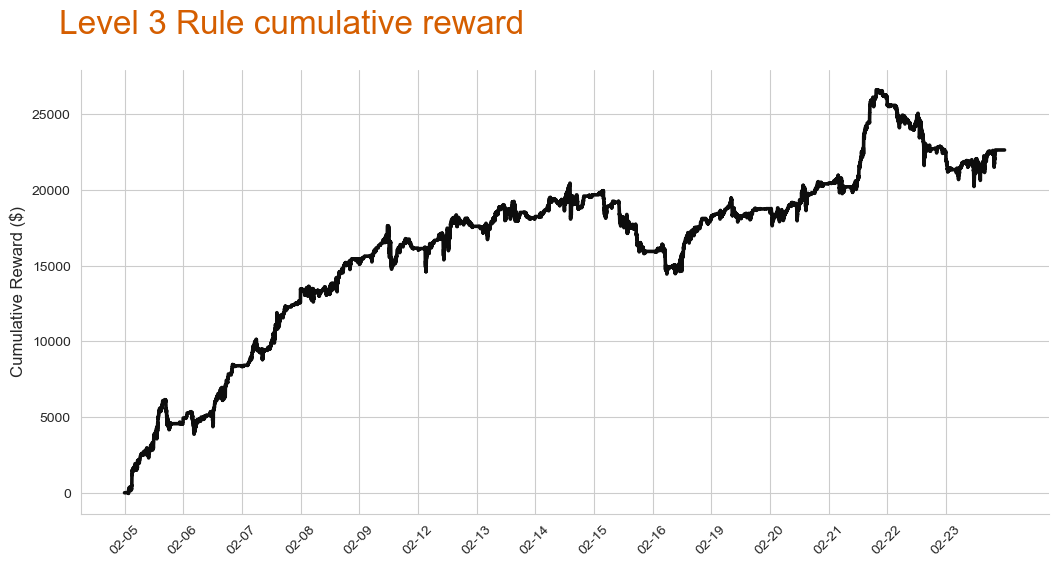

In [9]:
out_rule_3 = run_rule_3asset_discrete(
    df_3,
    col_a="CLJ4",
    col_b="RBJ4",
    col_c="HOJ4",
    mult_a=1000.0,
    mult_b=42000.0,
    mult_c=42000.0,
)
print(out_rule_3["metrics"])
plot_trading_time_cum(out_rule_3["cum"], "Level 3 Rule cumulative reward")

{'mean_daily_pnl_$': 5217.779999999882, 'max_drawdown_daily_$': -683.0000000000218}
{'mean_daily_pnl_$': 3622.700000000061, 'max_drawdown_daily_$': -3617.799999999903}


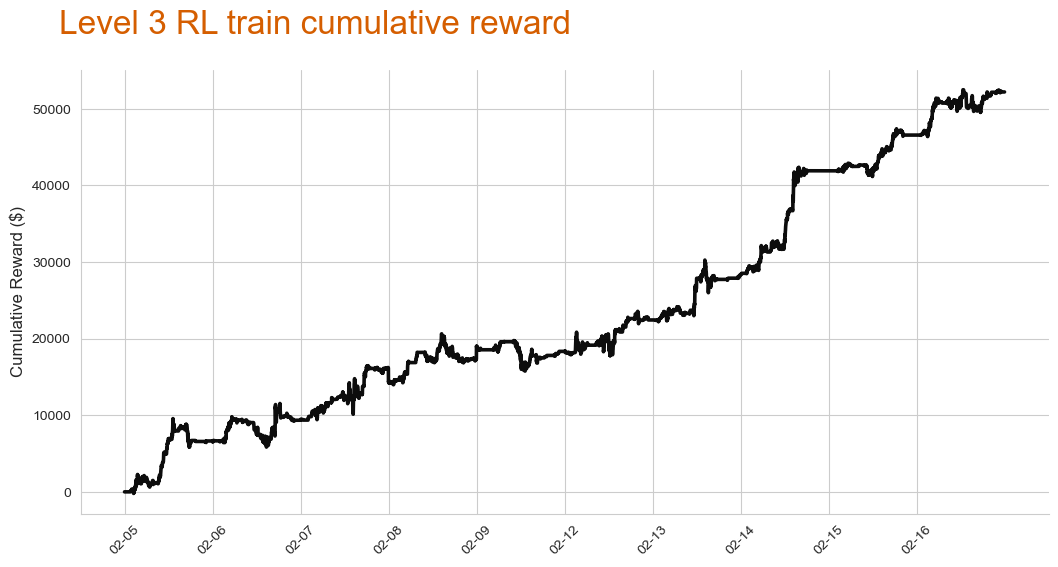

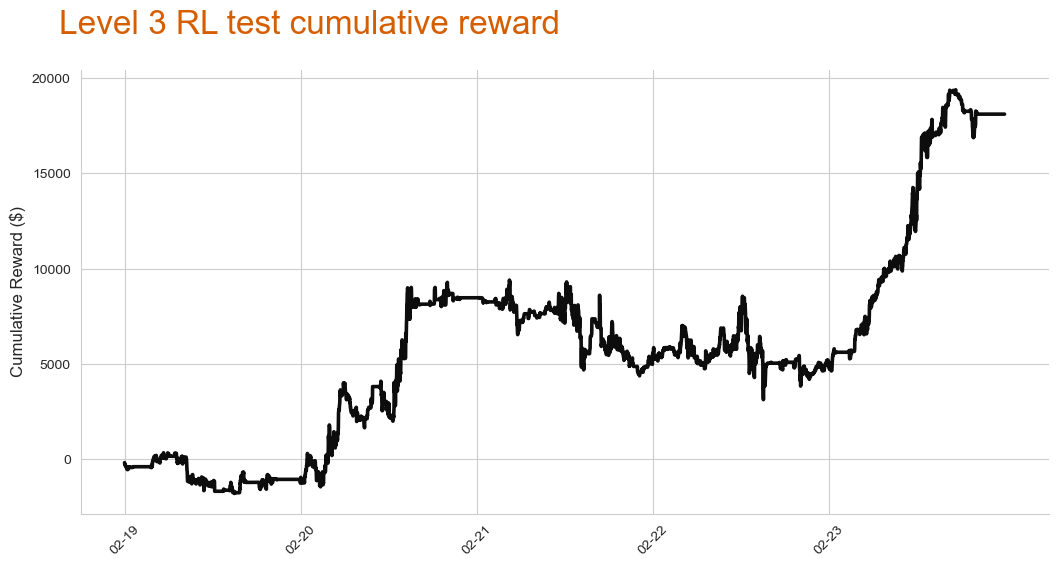

In [10]:
out_rl_3 = train_q_learning_3asset_discrete_adaptive(
    df_3,
    col_a="CLJ4",
    col_b="RBJ4",
    col_c="HOJ4",
    train_end="2024-02-18",
    mult_a=1000.0,
    mult_b=42000.0,
    mult_c=42000.0,
    epochs=100,
    eps_start=0.7,
    eps_end=0.2,   
    inv_penalty=10,
    z_step=0.5,
    lr=0.1,
)
print(out_rl_3["train_metrics"])
print(out_rl_3["test_metrics"])
plot_trading_time_cum(out_rl_3["train_cum_pnl"], "Level 3 RL train cumulative reward")
plot_trading_time_cum(out_rl_3["test_cum_pnl"], "Level 3 RL test cumulative reward")

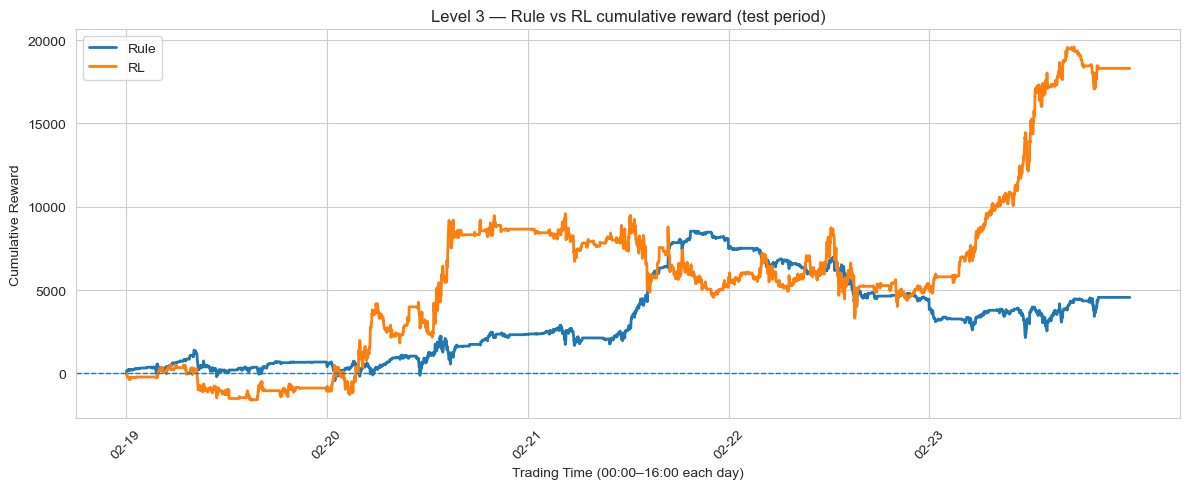

In [94]:


train_end = "2024-02-18"

rule_cum = out_rule_3["cum"]
rl_cum   = out_rl_3["test_cum_pnl"]

# restrict rule to the test period and re-zero so both start at 0
rule_test = rule_cum[rule_cum.index > pd.Timestamp(train_end)].copy()
rule_test = rule_test - rule_test.iloc[0]
rl_test   = rl_cum - rl_cum.iloc[0]

# trading-time x-axis so overnight gaps don't stretch the plot
aligned = pd.concat(
    [rule_test.rename("Rule"), rl_test.rename("RL")], axis=1
).dropna(how="all")

x = np.arange(len(aligned))
dates = aligned.index.normalize()
unique_dates, first_pos = np.unique(dates.values, return_index=True)
unique_dates = pd.to_datetime(unique_dates)

plt.figure(figsize=(12, 5))
plt.plot(x, aligned["Rule"].values, label="Rule", linewidth=2)
plt.plot(x, aligned["RL"].values,   label="RL",   linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(first_pos, [d.strftime("%m-%d") for d in unique_dates], rotation=45)
plt.xlabel("Trading Time (00:00–16:00 each day)")
plt.ylabel("Cumulative Reward")
plt.title("Level 3 — Rule vs RL cumulative reward (test period)")
plt.legend()
plt.tight_layout()
plt.show()


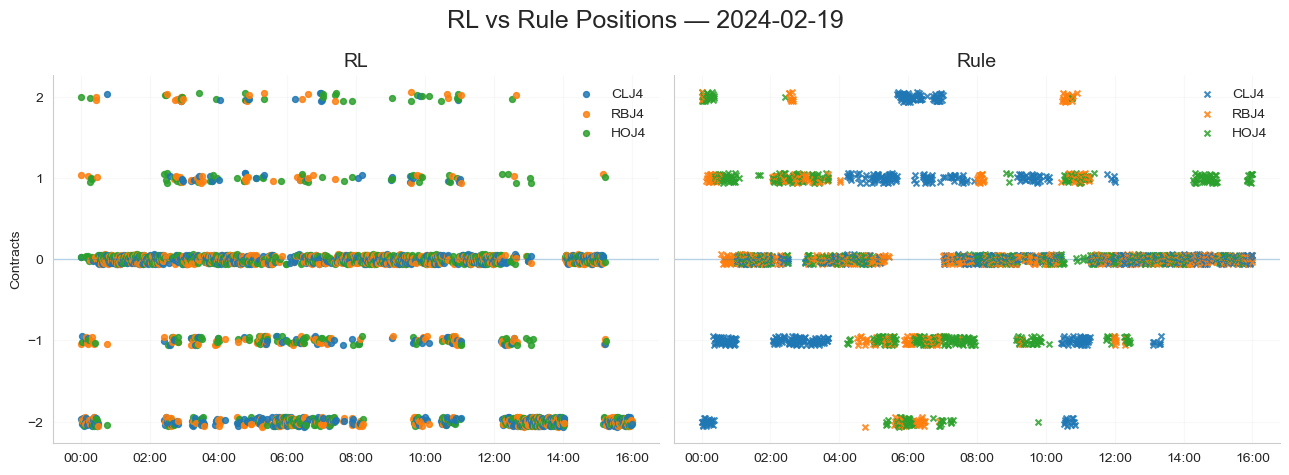

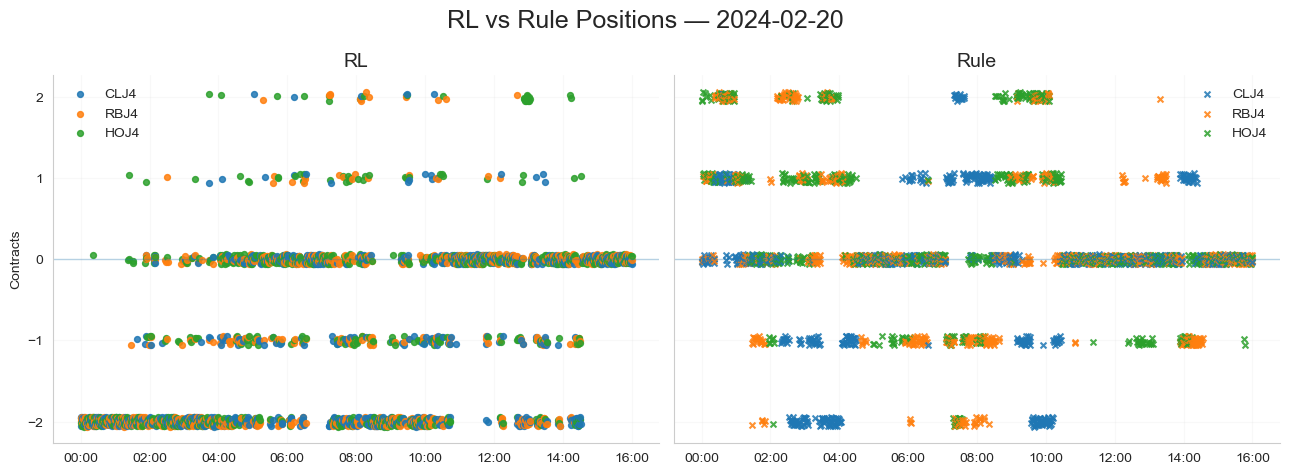

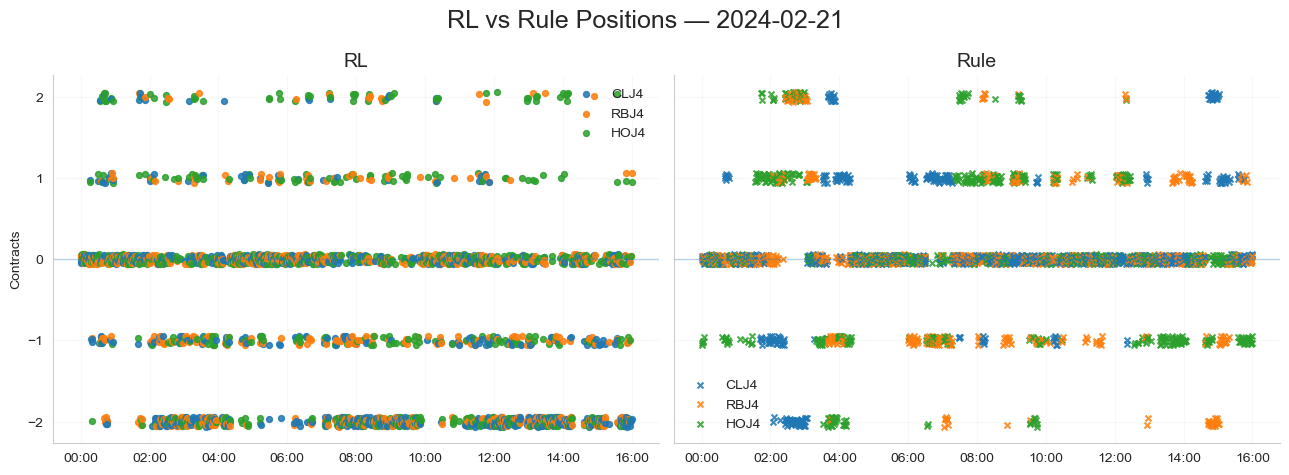

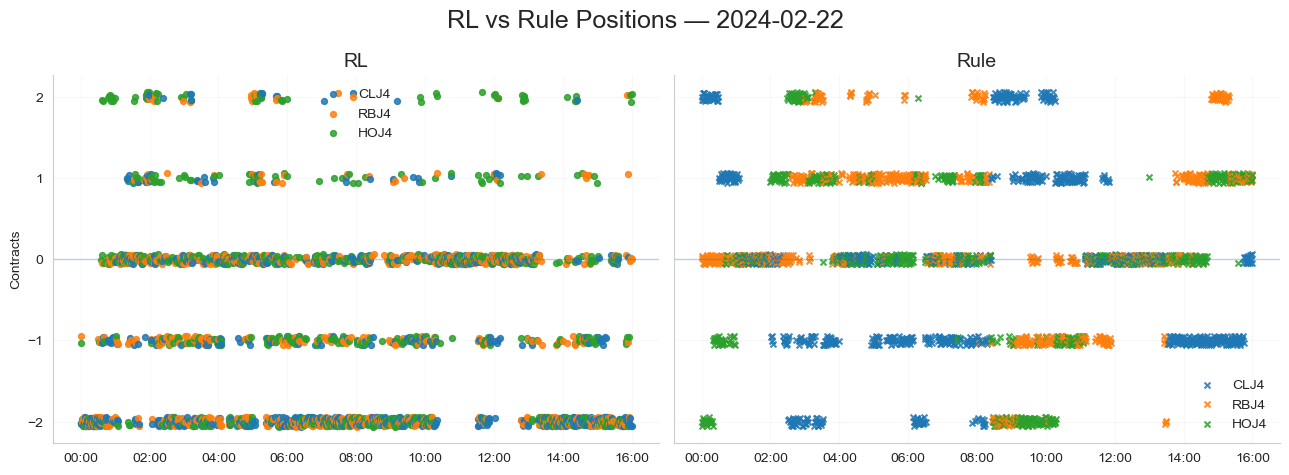

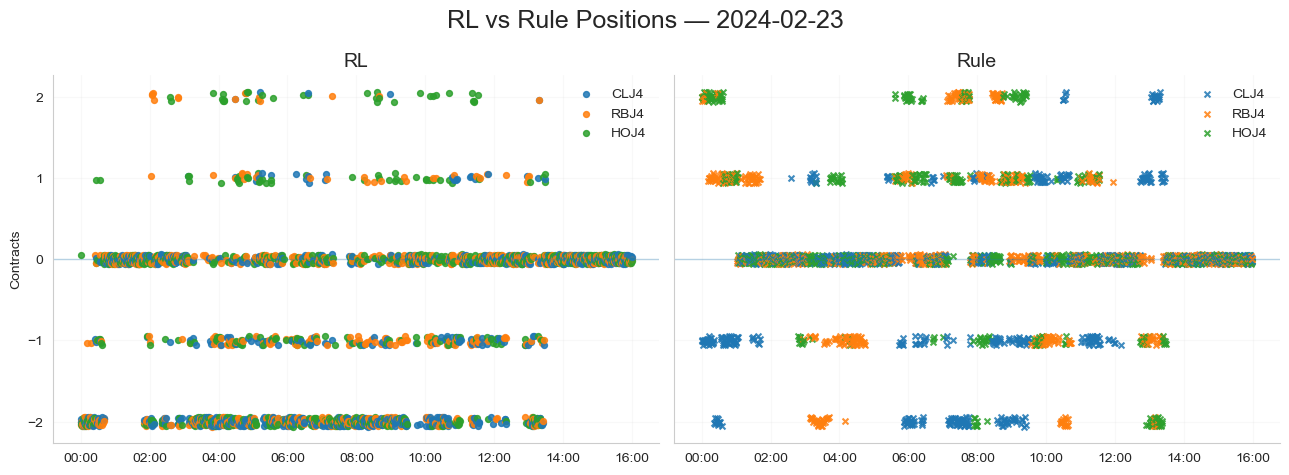

In [11]:
def _scatter_positions_with_overlap_control(
    ax,
    df_day: pd.DataFrame,
    asset_specs,
    *,
    marker="o",
    dot_size=18,
    alpha=0.85,
    jitter=0.06,
    rng=None,
):
    """
    Plot one day of positions with overlap control.

    asset_specs: list of tuples
        [(column_name, label, color), ...]
    """

    if rng is None:
        rng = np.random.default_rng(0)

    # loop over timestamps, not assets
    for ts, row in df_day.iterrows():
        order = rng.permutation(len(asset_specs))

        for idx in order:
            col_name, label, color = asset_specs[idx]
            y = float(row[col_name])

            # tiny vertical jitter so overlapping dots become visible
            y_plot = y + rng.uniform(-jitter, jitter)

            ax.scatter(
                ts,
                y_plot,
                s=dot_size,
                alpha=alpha,
                marker=marker,
                color=color,
            )

    # add legend manually once
    handles = []
    for _, label, color in asset_specs:
        h = ax.scatter([], [], s=dot_size, color=color, alpha=alpha, marker=marker, label=label)
        handles.append(h)

    return handles


def plot_rl_vs_rule_side_by_side_3asset(
    out_rl,
    out_rule,
    *,
    col_base: str,
    col_h1: str,
    col_h2: str,
    leg: str = "test",
    trading_start: str = "00:00",
    trading_end: str = "16:00",
    dot_size: int = 18,
    alpha: float = 0.85,
    jitter: float = 0.06,
    seed: int = 0,
):
    """
    Compare RL vs Rule positions side by side for a 3-asset strategy.

    Fixes overlap by:
    1) randomizing plotting order at each timestamp
    2) adding tiny vertical jitter
    """

    rng = np.random.default_rng(seed)

    n_base_col = f"n_{col_base}"
    n_h1_col = f"n_{col_h1}"
    n_h2_col = f"n_{col_h2}"

    rl_key = f"{leg}_n"
    if rl_key not in out_rl:
        raise ValueError(f"Missing key '{rl_key}' in out_rl.")
    if "n" not in out_rule:
        raise ValueError("Missing key 'n' in out_rule.")

    df_rl = out_rl[rl_key][[n_base_col, n_h1_col, n_h2_col]].dropna().copy()
    df_rule = out_rule["n"][[n_base_col, n_h1_col, n_h2_col]].dropna().copy()

    # trading-hours filter
    t0 = pd.to_datetime(trading_start).time()
    t1 = pd.to_datetime(trading_end).time()

    df_rl = df_rl[(df_rl.index.time >= t0) & (df_rl.index.time <= t1)]
    df_rule = df_rule[(df_rule.index.time >= t0) & (df_rule.index.time <= t1)]

    common_days = sorted(
        set(df_rl.index.normalize().unique()).intersection(
            set(df_rule.index.normalize().unique())
        )
    )

    if not common_days:
        print("No common days to plot.")
        return

    asset_specs = [
        (n_base_col, col_base, "tab:blue"),
        (n_h1_col, col_h1, "tab:orange"),
        (n_h2_col, col_h2, "tab:green"),
    ]

    for day in common_days:
        g_rl = df_rl[df_rl.index.normalize() == day]
        g_rule = df_rule[df_rule.index.normalize() == day]

        if g_rl.empty and g_rule.empty:
            continue

        fig, axes = plt.subplots(
            1, 2, figsize=(13, 4.8), sharey=True, facecolor="white"
        )

        fig.suptitle(
            f"RL vs Rule Positions — {pd.to_datetime(day).strftime('%Y-%m-%d')}",
            fontsize=18,
            y=0.98,
        )

        # ---------------- RL panel ----------------
        ax = axes[0]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rl,
            asset_specs,
            marker="o",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("RL", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.set_ylabel("Contracts")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        # ---------------- Rule panel ----------------
        ax = axes[1]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rule,
            asset_specs,
            marker="x",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("Rule", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        plt.tight_layout()
        plt.show()
plot_rl_vs_rule_side_by_side_3asset(
    out_rl=out_rl_3,
    out_rule=out_rule_3,
    col_base="CLJ4",
    col_h1="RBJ4",
    col_h2="HOJ4",
    leg="test",
    trading_start="00:00",
    trading_end="16:00",
    seed=42,
)

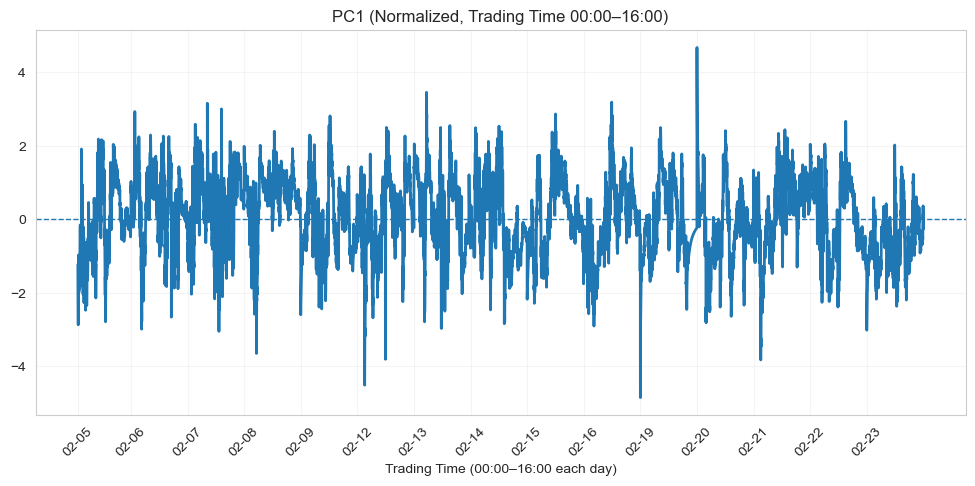

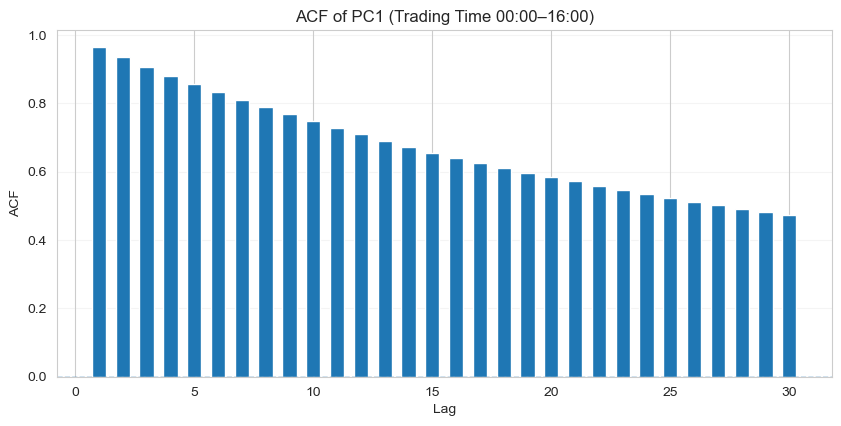

ADF Statistic: -12.897467329546707
p-value: 4.318195202790626e-24
Used lag: 11
N obs: 14343
Critical Values:
  1% : -3.4308060043723843
  5% : -2.861741533527916
 10% : -2.56687727155021
Conclusion: reject unit root at 5% -> PC1 looks stationary.
    lag       acf
0     1  0.965590
1     2  0.934099
2     3  0.906269
3     4  0.880495
4     5  0.856211
5     6  0.832531
6     7  0.811056
7     8  0.789135
8     9  0.768422
9    10  0.747972
10   11  0.727429
11   12  0.708968
12   13  0.690798
13   14  0.673055
14   15  0.655812
15   16  0.640088
16   17  0.625609
17   18  0.611354
18   19  0.597323
19   20  0.584090
20   21  0.571372
21   22  0.558072
22   23  0.545784
23   24  0.534124
24   25  0.522512
25   26  0.511695
26   27  0.501501
27   28  0.491915
28   29  0.482094
29   30  0.473124
{'adf_stat': -12.897467329546707, 'p_value': 4.318195202790626e-24, 'used_lag': 11, 'n_obs': 14343, 'crit_1%': -3.4308060043723843, 'crit_5%': -2.861741533527916, 'crit_10%': -2.56687727155021}


In [ ]:

# ============================================================
# 1) Rolling normalized PC1
# ============================================================
def add_normalized_pc1(
    df_prices: pd.DataFrame,
    window: int = 60,
    eps: float = 1e-8,
    col_prefix: str = "",
) -> pd.DataFrame:
    """
    Rolling EW PCA on price columns.

    At each time t:
        mu_t    = EW mean
        Cov_t   = EW covariance
        v1_t    = first eigenvector of Cov_t
        z_std_t = (z_t - mu_t) / sigma_t
        pc1_t   = v1_t' z_std_t

    Adds:
        pc1
        pc1_evr1
        pc1_w_<ticker>
    """
    df = df_prices.copy()
    tickers = list(df.columns)
    N = len(tickers)

    alpha = float(np.exp(-1.0 / window))
    z = df.values.astype(float)
    T = z.shape[0]

    A = np.zeros(N, dtype=float)
    B = np.zeros(N, dtype=float)
    M = np.zeros((N, N), dtype=float)

    pc1_hist = np.full(T, np.nan, dtype=float)
    evr1_hist = np.full(T, np.nan, dtype=float)
    w_hist = np.full((T, N), np.nan, dtype=float)

    prev_v1 = None

    for t in range(T):
        zt = z[t]
        mask = np.isfinite(zt).astype(float)

        A = alpha * A + mask * np.where(np.isfinite(zt), zt, 0.0)
        B = alpha * B + mask

        z_filled = np.where(np.isfinite(zt), zt, 0.0)
        M = alpha * M + np.outer(z_filled, z_filled)

        mu = A / np.maximum(B, eps)

        Cov = M / np.maximum(np.mean(B), eps) - np.outer(mu, mu)
        Cov = 0.5 * (Cov + Cov.T)

        diag = np.diag(Cov)
        diag = np.where(np.isfinite(diag), diag, eps)
        sigma = np.sqrt(np.maximum(diag, eps))

        vals, vecs = np.linalg.eigh(Cov)
        order = np.argsort(vals)[::-1]
        vals = np.maximum(vals[order], 0.0)
        vecs = vecs[:, order]

        total_var = vals.sum()
        evr1_hist[t] = vals[0] / total_var if total_var > eps else np.nan

        v1 = vecs[:, 0]

        # stabilize sign over time
        if prev_v1 is not None:
            if np.dot(v1, prev_v1) < 0:
                v1 = -v1
        else:
            if v1[0] < 0:
                v1 = -v1

        prev_v1 = v1.copy()

        z_std = (np.where(np.isfinite(zt), zt, mu) - mu) / sigma
        pc1_hist[t] = float(v1 @ z_std)
        w_hist[t] = v1

    out = df.copy()
    out[f"{col_prefix}pc1"] = pc1_hist
    out[f"{col_prefix}pc1_evr1"] = evr1_hist

    for i, tk in enumerate(tickers):
        out[f"{col_prefix}pc1_w_{tk}"] = w_hist[:, i]

    return out


# ============================================================
# 2) Plot PC1 in trading time (no overnight gaps)
# ============================================================
def plot_pc1_trading_time(
    df: pd.DataFrame,
    pc1_col: str = "pc1",
    title: str = "PC1 (Trading Time 00:00–16:00)",
    drop_warmup: int = 60,
):
    df = df.copy()
    df = df.between_time("00:00", "16:00")

    if drop_warmup > 0:
        df = df.iloc[drop_warmup:]

    df = df.dropna(subset=[pc1_col])

    if df.empty:
        print("No data to plot.")
        return

    x = np.arange(len(df))

    dates = df.index.normalize()
    unique_dates, first_pos = np.unique(dates.values, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    plt.figure(figsize=(12, 5))
    plt.plot(x, df[pc1_col].values, linewidth=2)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(first_pos, [d.strftime("%m-%d") for d in unique_dates], rotation=45)
    plt.xlabel("Trading Time (00:00–16:00 each day)")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


# ============================================================
# 3) ACF computation
# ============================================================
def compute_acf(
    series: pd.Series,
    max_lag: int = 30,
) -> pd.DataFrame:
    s = pd.Series(series).astype(float).dropna()

    rows = []
    for lag in range(1, max_lag + 1):
        rho = s.autocorr(lag=lag) if len(s) > lag else np.nan
        rows.append((lag, rho))

    return pd.DataFrame(rows, columns=["lag", "acf"])


# ============================================================
# 4) Plot ACF
# ============================================================
def plot_acf_trading_time(
    df: pd.DataFrame,
    pc1_col: str = "pc1",
    max_lag: int = 30,
    drop_warmup: int = 60,
    title: str = "ACF of PC1",
):
    d = df.copy()
    d = d.between_time("00:00", "16:00")

    if drop_warmup > 0:
        d = d.iloc[drop_warmup:]

    s = d[pc1_col].astype(float).dropna()
    acf_df = compute_acf(s, max_lag=max_lag)

    plt.figure(figsize=(10, 4.5))
    plt.bar(acf_df["lag"], acf_df["acf"], width=0.6)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(title)
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    return acf_df


# ============================================================
# 5) ADF test
# ============================================================
def run_adf_test(
    df: pd.DataFrame,
    pc1_col: str = "pc1",
    drop_warmup: int = 60,
    regression: str = "c",
    autolag: str = "AIC",
):
    d = df.copy()
    d = d.between_time("00:00", "16:00")

    if drop_warmup > 0:
        d = d.iloc[drop_warmup:]

    s = d[pc1_col].astype(float).dropna()

    if len(s) < 20:
        print("Not enough observations for ADF test.")
        return None

    res = adfuller(s, regression=regression, autolag=autolag)

    out = {
        "adf_stat": res[0],
        "p_value": res[1],
        "used_lag": res[2],
        "n_obs": res[3],
        "crit_1%": res[4]["1%"],
        "crit_5%": res[4]["5%"],
        "crit_10%": res[4]["10%"],
    }

    print("ADF Statistic:", out["adf_stat"])
    print("p-value:", out["p_value"])
    print("Used lag:", out["used_lag"])
    print("N obs:", out["n_obs"])
    print("Critical Values:")
    print("  1% :", out["crit_1%"])
    print("  5% :", out["crit_5%"])
    print(" 10% :", out["crit_10%"])

    if out["p_value"] < 0.05:
        print("Conclusion: reject unit root at 5% -> PC1 looks stationary.")
    else:
        print("Conclusion: fail to reject unit root at 5% -> PC1 may be non-stationary.")

    return out


# ============================================================
# 6) One wrapper to run everything
# ============================================================
def analyze_pc1_trading_hours(
    df_state_all: pd.DataFrame,
    tickers,
    window: int = 60,
    max_lag: int = 30,
    drop_warmup: int = 60,
):
    # keep only requested price columns
    df_prices = df_state_all[tickers].copy()

    # build normalized PC1
    df_pc1 = add_normalized_pc1(
        df_prices,
        window=window,
    )

    # plot PC1 in trading time
    plot_pc1_trading_time(
        df_pc1,
        pc1_col="pc1",
        title="PC1 (Normalized, Trading Time 00:00–16:00)",
        drop_warmup=drop_warmup,
    )

    # plot ACF
    acf_df = plot_acf_trading_time(
        df_pc1,
        pc1_col="pc1",
        max_lag=max_lag,
        drop_warmup=drop_warmup,
        title="ACF of PC1 (Trading Time 00:00–16:00)",
    )

    # run ADF
    adf_out = run_adf_test(
        df_pc1,
        pc1_col="pc1",
        drop_warmup=drop_warmup,
        regression="c",
        autolag="AIC",
    )

    return df_pc1, acf_df, adf_out


# ============================================================
# 7) Run on your data
# ============================================================

# choose symbols
tickers = ["CLJ4", "RBJ4", "HOJ4"]
# or:
# tickers = sym_active

df_pc1, acf_df, adf_out = analyze_pc1_trading_hours(
    df_state_all=df_state_all,
    tickers=tickers,
    window=60,
    max_lag=30,
    drop_warmup=60,
)

print(acf_df)
print(adf_out)

In this experiment, the normalized PC1 series does not exhibit a unit root, as indicated by the highly negative ADF statistic and near-zero p-value, allowing us to strongly reject non-stationarity. Instead, PC1 is stationary, fluctuating around a stable mean, but remains highly persistent due to strong autocorrelation. This suggests that PC1 captures a slow-moving common factor driving co-movement across assets, rather than a drifting trend, making it more suitable as a state or regime variable rather than a direct mean-reversion trading signal.

best horizon h* = 1   corr(signal, fwd_ret) = -0.0178


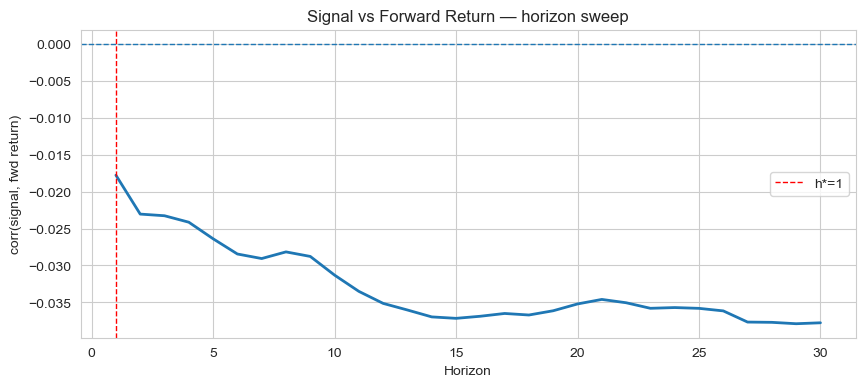

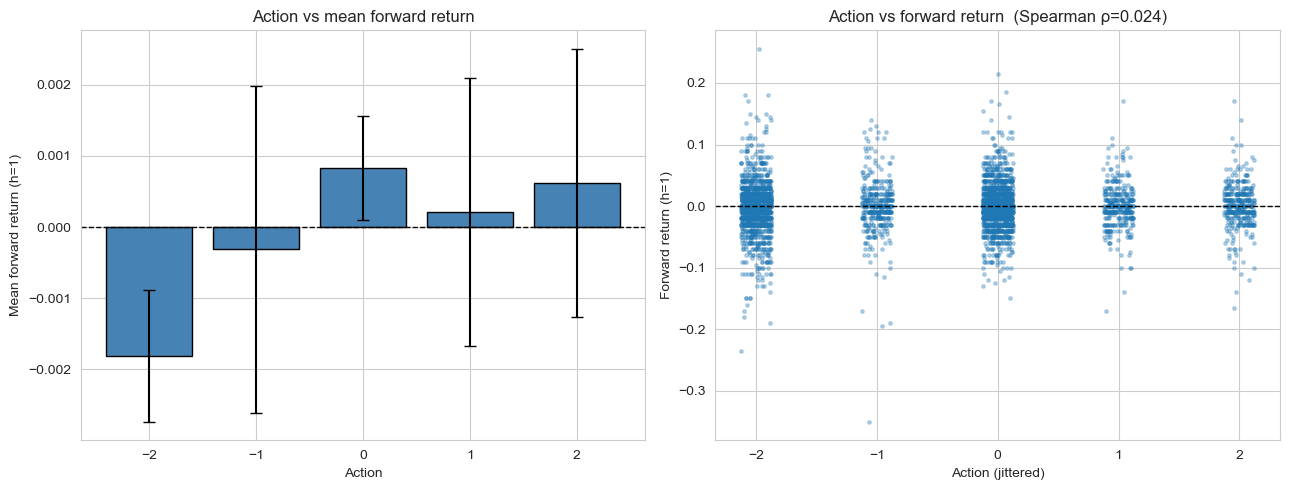

In [ ]:

# ============================================================
# 1) Find best horizon for signal vs forward return
# ============================================================

def signal_fwd_corr(df, signal_col, price_col, horizon,
                    start_date="2024-02-19"):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]
    s = d[signal_col].astype(float)
    fwd = d[price_col].shift(-horizon) - d[price_col]
    both = pd.concat([s.rename("s"), fwd.rename("r")], axis=1).dropna()
    if both.empty:
        return np.nan
    return both["s"].corr(both["r"])  # Pearson

horizons = range(1, 31)
corrs = np.array([
    signal_fwd_corr(df_3, "sig_a", "CLJ4", h) for h in horizons
], dtype=float)

best_idx = int(np.nanargmax(corrs))
best_h   = list(horizons)[best_idx]
best_c   = corrs[best_idx]


print(f"best horizon h* = {best_h}   corr(signal, fwd_ret) = {best_c:.4f}")

plt.figure(figsize=(10,4))
plt.plot(list(horizons), corrs, linewidth=2)
plt.axhline(0, ls="--", lw=1)
plt.axvline(best_h, ls="--", lw=1, color="red", label=f"h*={best_h}")
plt.xlabel("Horizon"); plt.ylabel("corr(signal, fwd return)")
plt.title("Signal vs Forward Return — horizon sweep")
plt.legend(); plt.show()


# ============================================================
# 2) Plot action vs forward return at best horizon
# ============================================================

def action_vs_fwd_return(df, price_col, action, horizon,
                         start_date="2024-02-19"):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]
    fwd = (d[price_col].shift(-horizon) - d[price_col]).rename("fwd_ret")

    a = action.sort_index().astype(float)
    a = a.between_time("00:00", "16:00")
    a = a[a.index >= pd.Timestamp(start_date)]
    a.name = "action"

    return pd.concat([a, fwd], axis=1).dropna()

action_CLJ4 = out_rl_3["test_actions"]["a_CLJ4"]
af = action_vs_fwd_return(df_3, "CLJ4", action_CLJ4, best_h)


rho, pval = spearmanr(af["action"], af["fwd_ret"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) mean fwd return per action bucket
axes[0].bar(grp.index.astype(int), grp["mean"],
            yerr=grp["std"]/np.sqrt(grp["count"]),
            capsize=4, color="steelblue", edgecolor="black")
axes[0].axhline(0, ls="--", lw=1, color="k")
axes[0].set_xlabel("Action")
axes[0].set_ylabel(f"Mean forward return (h={best_h})")
axes[0].set_title("Action vs mean forward return")

# (b) scatter
jitter = (np.random.rand(len(af)) - 0.5) * 0.25
axes[1].scatter(af["action"] + jitter, af["fwd_ret"], s=6, alpha=0.3)
axes[1].axhline(0, ls="--", lw=1, color="k")
axes[1].set_xlabel("Action (jittered)")
axes[1].set_ylabel(f"Forward return (h={best_h})")
axes[1].set_title(f"Action vs forward return  (Spearman ρ={rho:.3f})")

plt.tight_layout(); plt.show()


### When the signal becomes more predictive, the RL policy tends to follow it more.

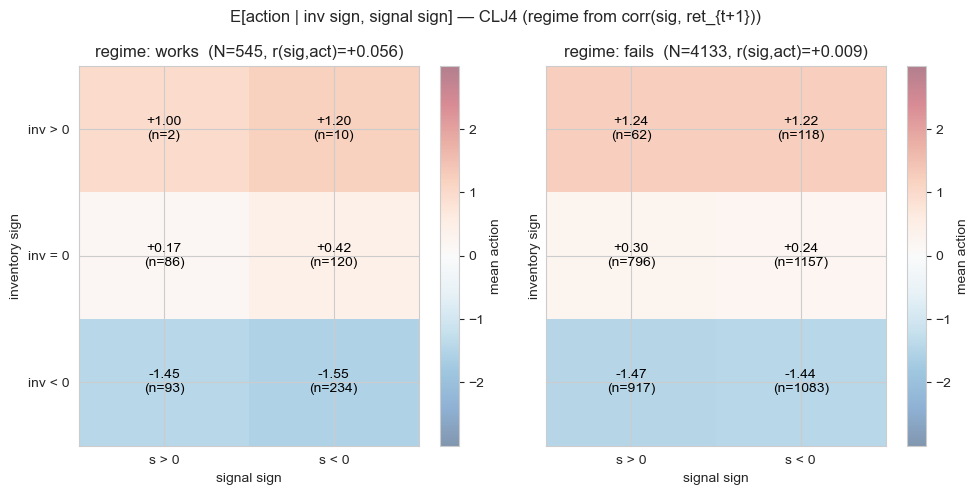

  regime     N  corr_signal_action  mean_sig_ret_corr
0  works   545            0.055912           0.070632
1  fails  4133            0.009139          -0.173195


In [ ]:

def plot_avg_action_inv_signal_sign(
    df: pd.DataFrame,
    *,
    signal_col: str,
    inventory_col: str,
    price_col: str,
    action: pd.Series,
    start_date: str = "2024-02-19",
    rolling_window: int = 60,
    fwd_horizon: int = 1,
    action_min: int = -2,
    action_max: int = 2,
    title: str | None = None,
):
    tmp = df.sort_index().copy()
    tmp = tmp.between_time("00:00", "16:00")
    tmp = tmp[tmp.index >= pd.Timestamp(start_date)]

    tmp = tmp[[signal_col, inventory_col, price_col]].copy()
    tmp["action"] = action.sort_index().astype(float)
    tmp["fwd_ret"] = tmp[price_col].shift(-fwd_horizon) - tmp[price_col]
    tmp = tmp.dropna()

    # regime from rolling corr(signal, fwd_ret_{t+h})
    tmp["sig_ret_corr"] = tmp[signal_col].rolling(rolling_window).corr(tmp["fwd_ret"])
    tmp = tmp.dropna(subset=["sig_ret_corr"])
    tmp["regime"] = np.where(tmp["sig_ret_corr"] > 0, "works", "fails")

    def inv_sign(x):
        if x > 0:
            return "inv > 0"
        if x < 0:
            return "inv < 0"
        return "inv = 0"

    def sig_sign(x):
        return "s > 0" if x > 0 else "s < 0"

    tmp["inv_sign"] = tmp[inventory_col].map(inv_sign)
    tmp["sig_sign"] = tmp[signal_col].map(sig_sign)

    row_order = ["inv > 0", "inv = 0", "inv < 0"]
    col_order = ["s > 0", "s < 0"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    regime_summary = []

    for ax, regime in zip(axes, ["works", "fails"]):
        sub = tmp[tmp["regime"] == regime].copy()

        mean_a = (
            sub.groupby(["inv_sign", "sig_sign"])["action"]
               .mean()
               .unstack("sig_sign")
               .reindex(index=row_order, columns=col_order)
        )
        counts = (
            sub.groupby(["inv_sign", "sig_sign"])["action"]
               .size()
               .unstack("sig_sign")
               .reindex(index=row_order, columns=col_order)
               .fillna(0)
               .astype(int)
        )

        # overall corr(signal, action) within regime
        if sub[signal_col].nunique() >= 2 and sub["action"].nunique() >= 2:
            overall_corr = sub[signal_col].corr(sub["action"])
        else:
            overall_corr = np.nan

        regime_summary.append(
            {
                "regime": regime,
                "N": len(sub),
                "corr_signal_action": overall_corr,
                "mean_sig_ret_corr": sub["sig_ret_corr"].mean(),
            }
        )

        im = ax.imshow(
            mean_a.values,
            aspect="auto",
            cmap="RdBu_r",
            vmin=action_min - 1,
            vmax=action_max + 1,
            alpha=0.5,
        )

        ax.set_xticks(np.arange(len(col_order)))
        ax.set_xticklabels(col_order)
        ax.set_yticks(np.arange(len(row_order)))
        ax.set_yticklabels(row_order)

        ax.set_xlabel("signal sign")
        ax.set_ylabel("inventory sign")
        ax.set_title(
            f"regime: {regime}  (N={len(sub)}, r(sig,act)={overall_corr:+.3f})"
        )

        for i in range(mean_a.shape[0]):
            for j in range(mean_a.shape[1]):
                v = mean_a.values[i, j]
                n = int(counts.values[i, j])
                if np.isfinite(v):
                    txt = f"{v:+.2f}\n(n={n})"
                else:
                    txt = "no obs"
                ax.text(
                    j, i, txt,
                    ha="center", va="center",
                    fontsize=10, color="black",
                )

        cbar = fig.colorbar(
            im, ax=ax, ticks=np.arange(action_min, action_max + 1)
        )
        cbar.set_label("mean action")

    fig.suptitle(
        title
        or "E[action | inventory sign, signal sign] — regime from corr(sig, ret_{t+h})"
    )
    plt.tight_layout()
    plt.show()

    regime_summary = pd.DataFrame(regime_summary)
    return tmp, regime_summary


df_reg = df_3.copy()
df_reg["n_CLJ4"] = out_rl_3["test_n"]["n_CLJ4"]

tmp_reg, regime_summary = plot_avg_action_inv_signal_sign(
    df=df_reg,
    signal_col="sig_a",
    inventory_col="n_CLJ4",
    price_col="CLJ4",
    action=out_rl_3["test_actions"]["a_CLJ4"],
    start_date="2024-02-19",
    rolling_window=60,
    fwd_horizon=1,
    action_min=-2,
    action_max=2,
    title="E[action | inv sign, signal sign] — CLJ4 (regime from corr(sig, ret_{t+1}))",
)

print(regime_summary)

accuracy = 0.7219


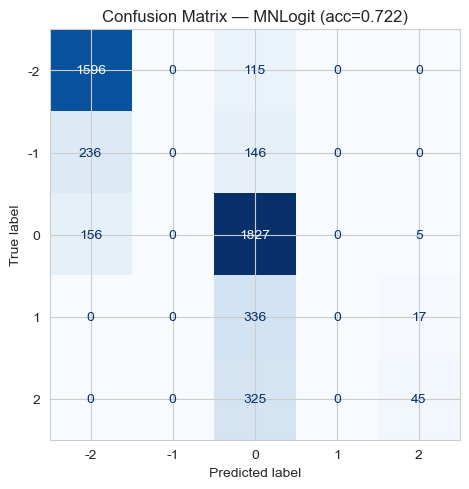

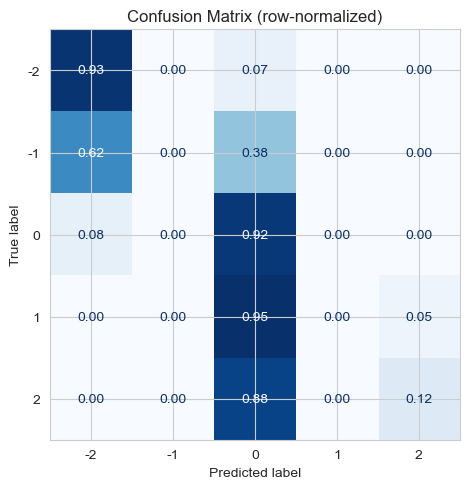


=== Coefficients (log-odds vs action 0) ===
        action -2 vs 0  action -1 vs 0  action 1 vs 0  action 2 vs 0
const          -4.0584         -3.2741        -1.7288        -1.7937
sig_a           7.1364         -8.1809        -3.9970       -28.2546
n_CLJ4         -3.3278         -2.0148         0.0174         1.3042

=== Standard errors ===
        action -2 vs 0  action -1 vs 0  action 1 vs 0  action 2 vs 0
const           0.1516          0.1201         0.0601         0.0634
sig_a           6.0327          6.8799         6.5903         7.0652
n_CLJ4          0.0943          0.0833         0.0934         0.1054

=== p-values ===
        action -2 vs 0  action -1 vs 0  action 1 vs 0  action 2 vs 0
const           0.0000          0.0000         0.0000         0.0000
sig_a           0.2368          0.2344         0.5442         0.0001
n_CLJ4          0.0000          0.0000         0.8524         0.0000

log-likelihood = -4039.99
pseudo R²      = 0.3646
n obs          = 4804


In [ ]:
def _prepare(df, cols, start_date="2024-02-19"):
    tmp = df.sort_index().copy()
    tmp = tmp.between_time("00:00", "16:00")
    tmp = tmp[tmp.index >= pd.Timestamp(start_date)]
    return tmp[cols].dropna().copy()


def fit_multinomial_policy(df, action, *, signal_col, inventory_col,
                           start_date="2024-02-19"):
    merged = df.join(action.rename("__a__"), how="inner")
    tmp = _prepare(merged, [signal_col, inventory_col, "__a__"], start_date)

    X = sm.add_constant(tmp[[signal_col, inventory_col]], has_constant="add")
    y = tmp["__a__"].astype(int)

    # baseline class = action 0
    uniq = sorted(y.unique())
    if 0 not in uniq:
        raise ValueError("action=0 not present — cannot use it as baseline")
    ordered = [0] + [a for a in uniq if a != 0]
    action_to_code = {a: i for i, a in enumerate(ordered)}
    code_to_action = {i: a for a, i in action_to_code.items()}

    y0 = y.map(action_to_code).astype(int)

    res = sm.MNLogit(y0, X).fit(method="newton", maxiter=200, disp=False)
    return res, code_to_action, tmp, X


def predict_policy(res, X, code_to_action):
    probs = np.asarray(res.predict(X))
    codes = probs.argmax(axis=1)
    return np.array([code_to_action[c] for c in codes])


# ---------- fit ----------
action_CLJ4 = out_rl_3["test_actions"]["a_CLJ4"]

res, code_to_action, tmp, X = fit_multinomial_policy(
    df=df_reg,
    action=action_CLJ4,
    signal_col="sig_a",
    inventory_col="n_CLJ4",
    start_date="2024-02-19",
)

y_true = tmp["__a__"].astype(int).values
y_pred = predict_policy(res, X, code_to_action)

# ---------- accuracy ----------
acc = (y_pred == y_true).mean()
print(f"accuracy = {acc:.4f}")

# ---------- confusion matrix ----------
labels = np.array(sorted(np.unique(np.concatenate([y_true, y_pred]))))
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title(f"Confusion Matrix — MNLogit (acc={acc:.3f})")
plt.tight_layout(); plt.show()

cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".2f"
)
ax.set_title("Confusion Matrix (row-normalized)")
plt.tight_layout(); plt.show()

# ---------- model parameters ----------
# MNLogit uses code 0 (= action 0) as the baseline.
# Each column of params is log-odds of action X vs action 0.
non_baseline = [code_to_action[i] for i in range(1, len(code_to_action))]

coef = res.params.copy()
coef.columns = [f"action {a} vs 0" for a in non_baseline]

se = res.bse.copy()
se.columns = coef.columns

pvals = res.pvalues.copy()
pvals.columns = coef.columns

print("\n=== Coefficients (log-odds vs action 0) ===")
print(coef.round(4))

print("\n=== Standard errors ===")
print(se.round(4))

print("\n=== p-values ===")
print(pvals.round(4))

print(f"\nlog-likelihood = {res.llf:.2f}")
print(f"pseudo R²      = {res.prsquared:.4f}")
print(f"n obs          = {int(res.nobs)}")


## Final Multinomial Logit Model (baseline = action 0)

### Class scores (log-odds vs 0)

$$
\eta_{-2} = -4.0584 + 7.1364 \cdot \text{sig\_a} - 3.3278 \cdot n_{\text{CLJ4}}
$$

$$
\eta_{-1} = -3.2741 - 8.1809 \cdot \text{sig\_a} - 2.0148 \cdot n_{\text{CLJ4}}
$$

$$
\eta_{0} = 0
$$

$$
\eta_{1} = -1.7288 - 3.9970 \cdot \text{sig\_a} + 0.0174 \cdot n_{\text{CLJ4}}
$$

$$
\eta_{2} = -1.7937 - 28.2546 \cdot \text{sig\_a} + 1.3042 \cdot n_{\text{CLJ4}}
$$

---

### Decision Rule

$$
\hat a_t = \arg\max_{k \in \{-2,-1,0,1,2\}} \eta_k
$$

---

### Probabilities

$$
P(a_t = k) = \frac{e^{\eta_k}}{e^{\eta_{-2}} + e^{\eta_{-1}} + 1 + e^{\eta_1} + e^{\eta_2}}
$$